# Pre-processing & QA/QC

## Importing required packages 

In [1]:
library(dplyr)
library(Seurat)
library(patchwork)
library(stringr)
library(ggplot2)
library(hdf5r)
library(repr)
library(RColorBrewer)
library(tidyverse)
library(scDblFinder)
library(BiocParallel)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()     masks stats::filter()
✖ purrr::flatten_df() masks hdf5r::flatten_df()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loadi

## Loading raw data


In [2]:
dir1 = readline(prompt = "Please enter user directory to load raw data up till before the file name: ") 
# e.g., "../raw_data/" (the file name changes and hence will directly be added in the function params

Please enter user directory to load raw data up till before the file name:  ../additional data/


Depending on the format of the raw sequencing data, please run one of the following code cells 
- if the data has .h5 extension, run the first.
- if the data has the count matrices, run the second

In [3]:
# WT 
Unfilt_WT_S1 <- Read10X_h5(paste0(dir1, "WT_S1.h5"), use.names = TRUE, unique.features = TRUE)
Unfilt_WT_S2 <- Read10X_h5(paste0(dir1, "WT_S2.h5"), use.names = TRUE, unique.features = TRUE)
Unfilt_WT_S3 <- Read10X_h5(paste0(dir1, "WT_S3.h5"), use.names = TRUE, unique.features = TRUE)
Unfilt_WT_S4 <- Read10X_h5(paste0(dir1, "WT_S4.h5"), use.names = TRUE, unique.features = TRUE)

# C246X
Unfilt_C246X_S1 <- Read10X_h5(paste0(dir1, "C246X_S1.h5"), use.names = TRUE, unique.features = TRUE)
Unfilt_C246X_S2 <- Read10X_h5(paste0(dir1, "C246X_S2.h5"), use.names = TRUE, unique.features = TRUE)
Unfilt_C246X_S3 <- Read10X_h5(paste0(dir1, "C246X_S3.h5"), use.names = TRUE, unique.features = TRUE)

# 362DEL
Unfilt_362del_S1 <- Read10X_h5(paste0(dir1, "DEL362_S1.h5"), use.names = TRUE, unique.features = TRUE)
Unfilt_362del_S2 <- Read10X_h5(paste0(dir1, "DEL362_S2.h5"), use.names = TRUE, unique.features = TRUE)
Unfilt_362del_S3 <- Read10X_h5(paste0(dir1, "DEL362_S3.h5"), use.names = TRUE, unique.features = TRUE)

In [3]:
# WT 
Unfilt_WT_S1 <- Read10X(paste0(dir1, "WT/WT_counts_matrix_1 (midbrain)/"), unique.features = TRUE)
Unfilt_WT_S2 <- Read10X(paste0(dir1, "WT/WT_counts_matrix_2 (whole brain)/"), unique.features = TRUE)

# C246X
Unfilt_C246X_S1 <- Read10X(paste0(dir1, "C246X/C246X_counts_matrix_1 (midbrain)/"), unique.features = TRUE)
Unfilt_C246X_S2 <- Read10X(paste0(dir1, "C246X/C246X_counts_matrix_2 (whole brain)/"), unique.features = TRUE)

## Creating Seurat objects 

Depending on the format of the raw sequencing data, please run one of the following code cells
- if the data has .h5 extension, run the first.
- if the data has the count matrices, run the second

In [3]:
# WT 
Unfilt_WT_S1_SRAT <- CreateSeuratObject(counts = Unfilt_WT_S1, project = "NOVO_WHOLE_SAMPLE_WT_1", min.cells = 3, min.features = 200)
Unfilt_WT_S2_SRAT <- CreateSeuratObject(counts = Unfilt_WT_S2, project = "NOVO_WHOLE_SAMPLE_WT_2", min.cells = 3, min.features = 200)
Unfilt_WT_S3_SRAT <- CreateSeuratObject(counts = Unfilt_WT_S3, project = "NOVO_WHOLE_SAMPLE_WT_3", min.cells = 3, min.features = 200)
Unfilt_WT_S4_SRAT <- CreateSeuratObject(counts = Unfilt_WT_S4, project = "NOVO_WHOLE_SAMPLE_WT_4", min.cells = 3, min.features = 200)

# C246X
Unfilt_C246X_S1_SRAT <- CreateSeuratObject(counts = Unfilt_C246X_S1, project = "NOVO_WHOLE_SAMPLE_C246X_1", min.cells = 3, min.features = 200)
Unfilt_C246X_S2_SRAT <- CreateSeuratObject(counts = Unfilt_C246X_S2, project = "NOVO_WHOLE_SAMPLE_C246X_2", min.cells = 3, min.features = 200)
Unfilt_C246X_S3_SRAT <- CreateSeuratObject(counts = Unfilt_C246X_S3, project = "NOVO_WHOLE_SAMPLE_C246X_3", min.cells = 3, min.features = 200)

# 362del
Unfilt_362del_S1_SRAT <- CreateSeuratObject(counts = Unfilt_362del_S1, project = "NOVO_WHOLE_SAMPLE_362del_1", min.cells = 3, min.features = 200)
Unfilt_362del_S2_SRAT <- CreateSeuratObject(counts = Unfilt_362del_S2, project = "NOVO_WHOLE_SAMPLE_362del_2", min.cells = 3, min.features = 200)
Unfilt_362del_S3_SRAT <- CreateSeuratObject(counts = Unfilt_362del_S3, project = "NOVO_WHOLE_SAMPLE_362del_3", min.cells = 3, min.features = 200)

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


In [4]:
# WT 
Unfilt_WT_S1_SRAT <- CreateSeuratObject(counts = Unfilt_WT_S1, project = "NOVO_WHOLE_SAMPLE_WT_1", min.cells = 3, min.features = 200)
Unfilt_WT_S2_SRAT <- CreateSeuratObject(counts = Unfilt_WT_S2, project = "NOVO_WHOLE_SAMPLE_WT_2", min.cells = 3, min.features = 200)

# C246X
Unfilt_C246X_S1_SRAT <- CreateSeuratObject(counts = Unfilt_C246X_S1, project = "NOVO_WHOLE_SAMPLE_C246X_1", min.cells = 3, min.features = 200)
Unfilt_C246X_S2_SRAT <- CreateSeuratObject(counts = Unfilt_C246X_S2, project = "NOVO_WHOLE_SAMPLE_C246X_2", min.cells = 3, min.features = 200)

## Merging Seurat objects + forming metadata object

Depending on the format of the raw sequencing data, please run one of the first 2 code cells in this section

- if the data has .h5 extension, run the first.
- if the data has the count matrices, run the second

In [13]:
# first merge samples for each genotype

Unfilt_WTall_SRAT <- merge(Unfilt_WT_S1_SRAT, y = c(Unfilt_WT_S2_SRAT, Unfilt_WT_S3_SRAT, Unfilt_WT_S4_SRAT), add.cell.ids = c("S1", "S2", "S3", "s4"), project = "NOVO_WHOLE_WT")
Unfilt_C246Xall_SRAT <- merge(Unfilt_C246X_S1_SRAT, y = c(Unfilt_C246X_S2_SRAT, Unfilt_C246X_S3_SRAT), add.cell.ids = c("S1", "S2", "S3"), project = "NOVO_WHOLE_C246X")
Unfilt_362all_SRAT <- merge(Unfilt_362del_S1_SRAT, y = c(Unfilt_362del_S2_SRAT, Unfilt_362del_S3_SRAT), add.cell.ids = c("S1", "S2", "S3"), project = "NOVO_WHOLE_362DEL")

# then merge genotypes to get one Seurat object
Unfilt_NOVOall_SRAT <- merge(Unfilt_WTall_SRAT, y = c(Unfilt_C246Xall_SRAT, Unfilt_362all_SRAT), add.cell.ids = c("WT", "C246X", "362del"), project = "NOVO_WHOLE_ALL")

In [30]:
# first merge samples for each genotype 

Unfilt_WTall_SRAT <- merge(Unfilt_WT_S1_SRAT, y = Unfilt_WT_S2_SRAT, add.cell.ids = c("S1", "S2"), project = "NOVO_WHOLE_WT")
Unfilt_C246Xall_SRAT <- merge(Unfilt_C246X_S1_SRAT, y = Unfilt_C246X_S2_SRAT, add.cell.ids = c("S1", "S2"), project = "NOVO_WHOLE_C246X")

# then merge genotypes to get one Seurat object
Unfilt_NOVOall_SRAT <- merge(Unfilt_WTall_SRAT, y = Unfilt_C246Xall_SRAT, add.cell.ids = c("WT", "C246X"), project = "NOVO_WHOLE_ALL")

In [31]:
#### forming metadata object from Seurat object ####

## Add mitochondrial and ribosomal genes to metadata (If many 0's check capitalisation of MT vs mt for organism)
Unfilt_NOVOall_SRAT[["percent.mt"]] <- PercentageFeatureSet(Unfilt_NOVOall_SRAT, pattern = "^mt-")
Unfilt_NOVOall_SRAT[["percent.rb"]] <- PercentageFeatureSet(Unfilt_NOVOall_SRAT, pattern = "^RP[SL]")

## Add a metadata column for viewing all samples at the same time
Unfilt_NOVOall_SRAT[["ALL"]] <- "view_all"

## Add number of genes per UMI for each cell and mitochondrial ratio to metadata

# UMI
Unfilt_NOVOall_SRAT$log10GenesPerUMI <- log10(Unfilt_NOVOall_SRAT$nFeature_RNA) / log10(Unfilt_NOVOall_SRAT$nCount_RNA)

# Compute percent mito ratio
Unfilt_NOVOall_SRAT$mitoRatio <- PercentageFeatureSet(object = Unfilt_NOVOall_SRAT, pattern = "^mt-")
Unfilt_NOVOall_SRAT$mitoRatio <- Unfilt_NOVOall_SRAT@meta.data$mitoRatio / 100

## New metadata frame for deeper QC
Unfilt_NOVOall_SRAT_metadata <- Unfilt_NOVOall_SRAT@meta.data

# Make a column with cell ID's
Unfilt_NOVOall_SRAT_metadata$cells <- rownames(Unfilt_NOVOall_SRAT_metadata)

# Create a new column with genotype (uncomment if running the 
Unfilt_NOVOall_SRAT_metadata = Unfilt_NOVOall_SRAT_metadata %>%
                                mutate(genotype = case_when(
                                                    str_detect(cells, "WT") ~ "WT",
                                                    str_detect(cells, "C246X") ~ "C246X",
                                                    str_detect(cells, "362") ~ "362del")) %>%
                                mutate(orig.ident = case_when(
                                                        str_detect(cells, "WT_S1") ~ "WT_S1",
                                                        str_detect(cells, "WT_S2") ~ "WT_S2",
                                                        str_detect(cells, "C246X_S1") ~ "C246X_S1",
                                                        str_detect(cells, "C246X_S2") ~ "C246X_S2"))

# Add the metadata from dataframe into the seurat object
Unfilt_NOVOall_SRAT@meta.data <- Unfilt_NOVOall_SRAT_metadata

In [32]:
# add a sample column to have each sample as a different colour, add cell count col to count cells by sample and genotype
# uncomment the lines if running the old raw data files

Unfilt_NOVOall_SRAT_metadata_final = Unfilt_NOVOall_SRAT_metadata %>% 
    mutate(sample = case_when(
                        str_detect(cells, "_S1") ~ "1",
                        str_detect(cells, "_S2") ~ "2",
                        str_detect(cells, "_S3") ~ "3",
                        str_detect(cells, "_S4") ~ "4")) %>%
    group_by(orig.ident) %>%  
    mutate(cell_count = n()) %>% # not using the count function bc all the other cols will disappear
    ungroup()

Note that if you only want to do the preprocessing steps for one sample, run the following code block. Else, skip this.

In [ ]:
# choose sample 
sample_number = readline(prompt = "Please enter the sample you would like to work on: ") # please enter only the number

# filter the object
Unfilt_NOVOall_SRAT@meta.data = Unfilt_NOVOall_SRAT@meta.data %>%
                                    filter(sample == sample_number)

Unfilt_NOVOall_SRAT_metadata_final = Unfilt_NOVOall_SRAT@meta.data

Save the files to rds objects to load later

In [34]:
# save unfiltered Seurat object to load later 
user_file_directory_unfiltsrat = readline(prompt = "Please enter file directory to save Unfilt_NOVOall_SRAT: ") # remember to add .rds extension after file name 
saveRDS(Unfilt_NOVOall_SRAT, file = user_file_directory_unfiltsrat) 

Please enter file directory to save Unfilt_NOVOall_SRAT:  ../data_files2/Unfilt_NOVOall_SRAT.rds


In [11]:
# save unfiltered metadata to load later
user_file_directory_unfiltmeta = readline(prompt = "Please enter file directory to save Unfilt_NOVOall_SRAT_metadata_final: ") # remember to add .rds extension after file name
saveRDS(Unfilt_NOVOall_SRAT_metadata_final, file = user_file_directory_unfiltmeta) 

Please enter file directory to save Unfilt_NOVOall_SRAT_metadata_final:  ../data_files2/Unfilt_NOVOall_SRAT_metadata_final.rds


In [33]:
# load both the files
Unfilt_NOVOall_SRAT = readRDS(user_file_directory_unfiltsrat)
Unfilt_NOVOall_SRAT_metadata_final = readRDS(user_file_directory_unfiltmeta)

## ***Unfiltered data visualisation***

## Looking at number of cells per sample and genotype

### Per sample

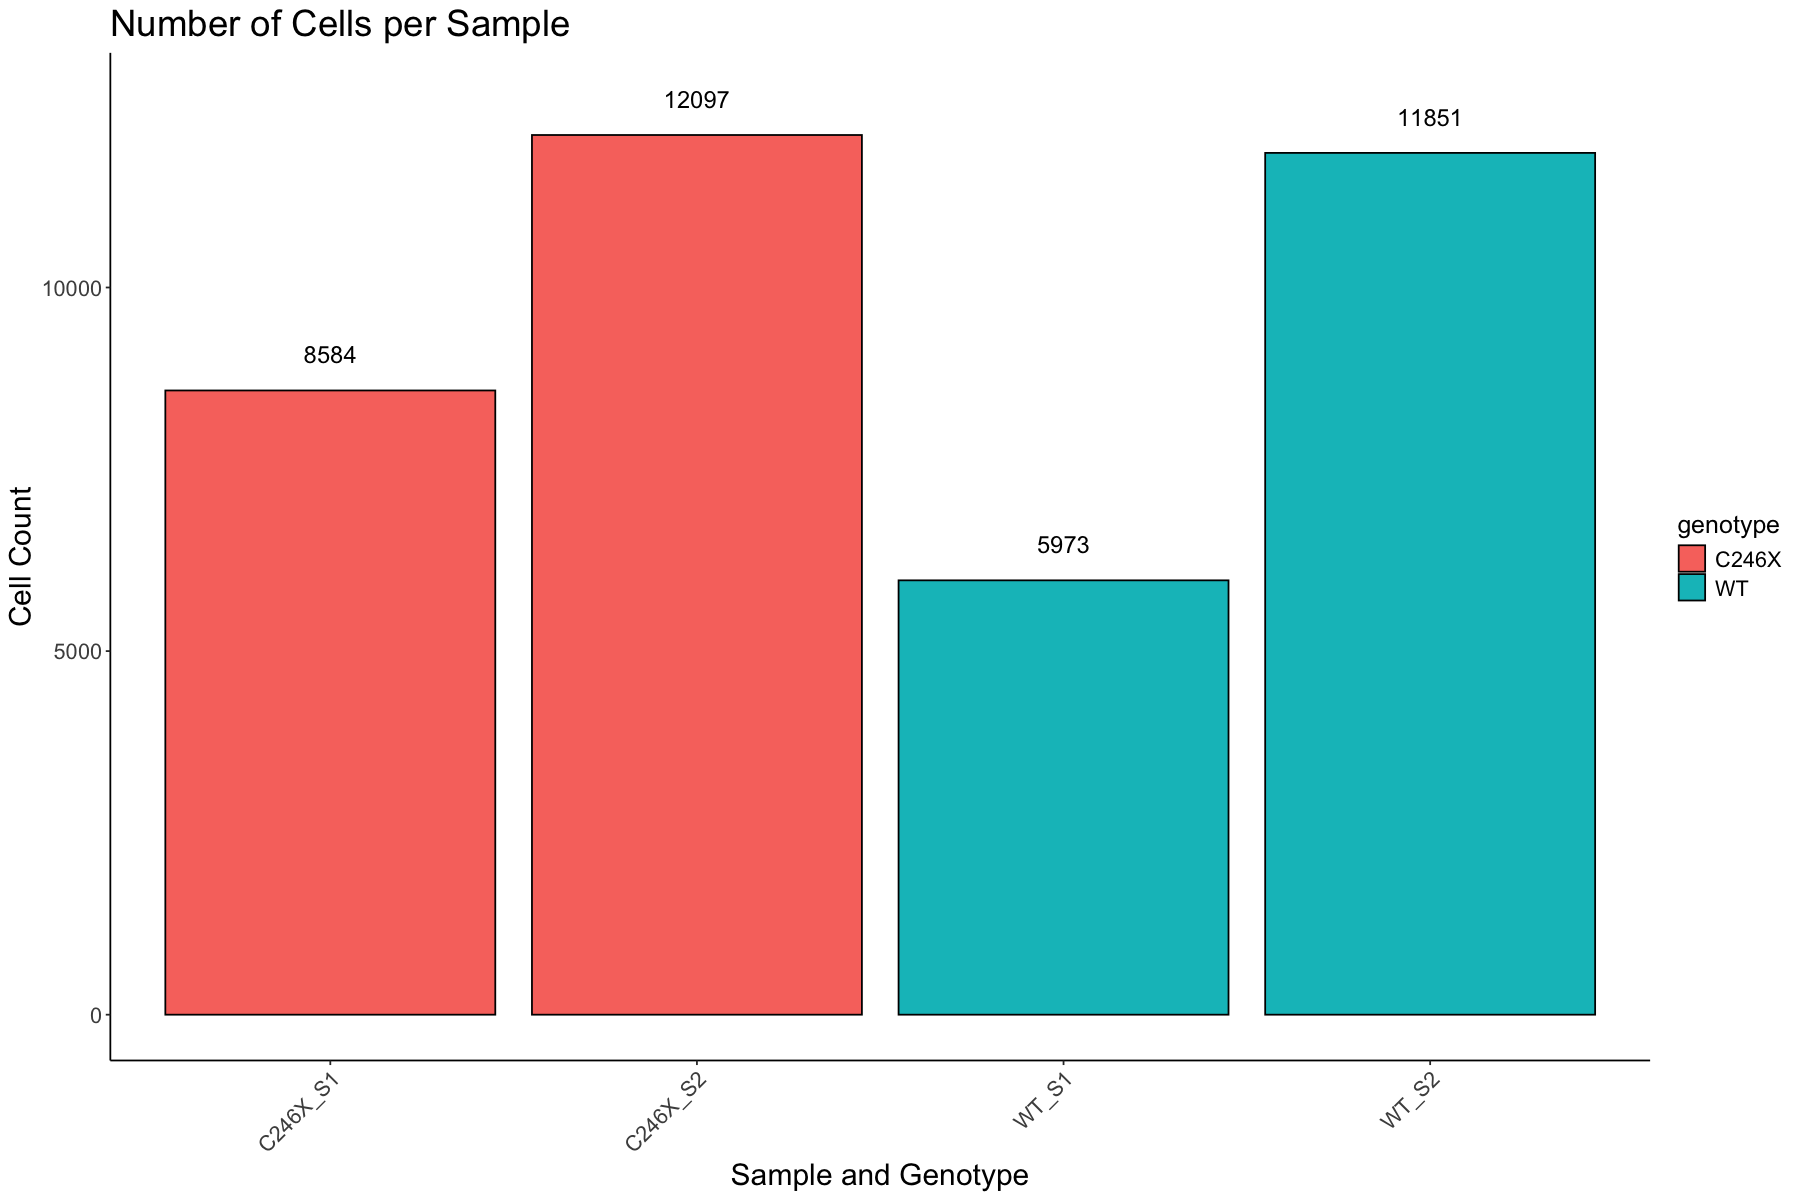

In [13]:
options(repr.plot.width=15, repr.plot.height=10)

Unfilt_NOVOall_SRAT_metadata_final %>%
  distinct(orig.ident, .keep_all = TRUE) %>% # remove the duplicate values so we can have one value per row, keep all cols
  ggplot(aes(x = orig.ident, y = cell_count)) + 
  	geom_col(aes(fill = genotype), color = "black") + 
    geom_text(aes(label = cell_count), nudge_y = 500, size = 5) +
    theme_classic() + 
    labs(x = "Sample and Genotype", y = "Cell Count") + 
    ggtitle("Number of Cells per Sample") + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 22))
    

### Per genotype

[1] 38505


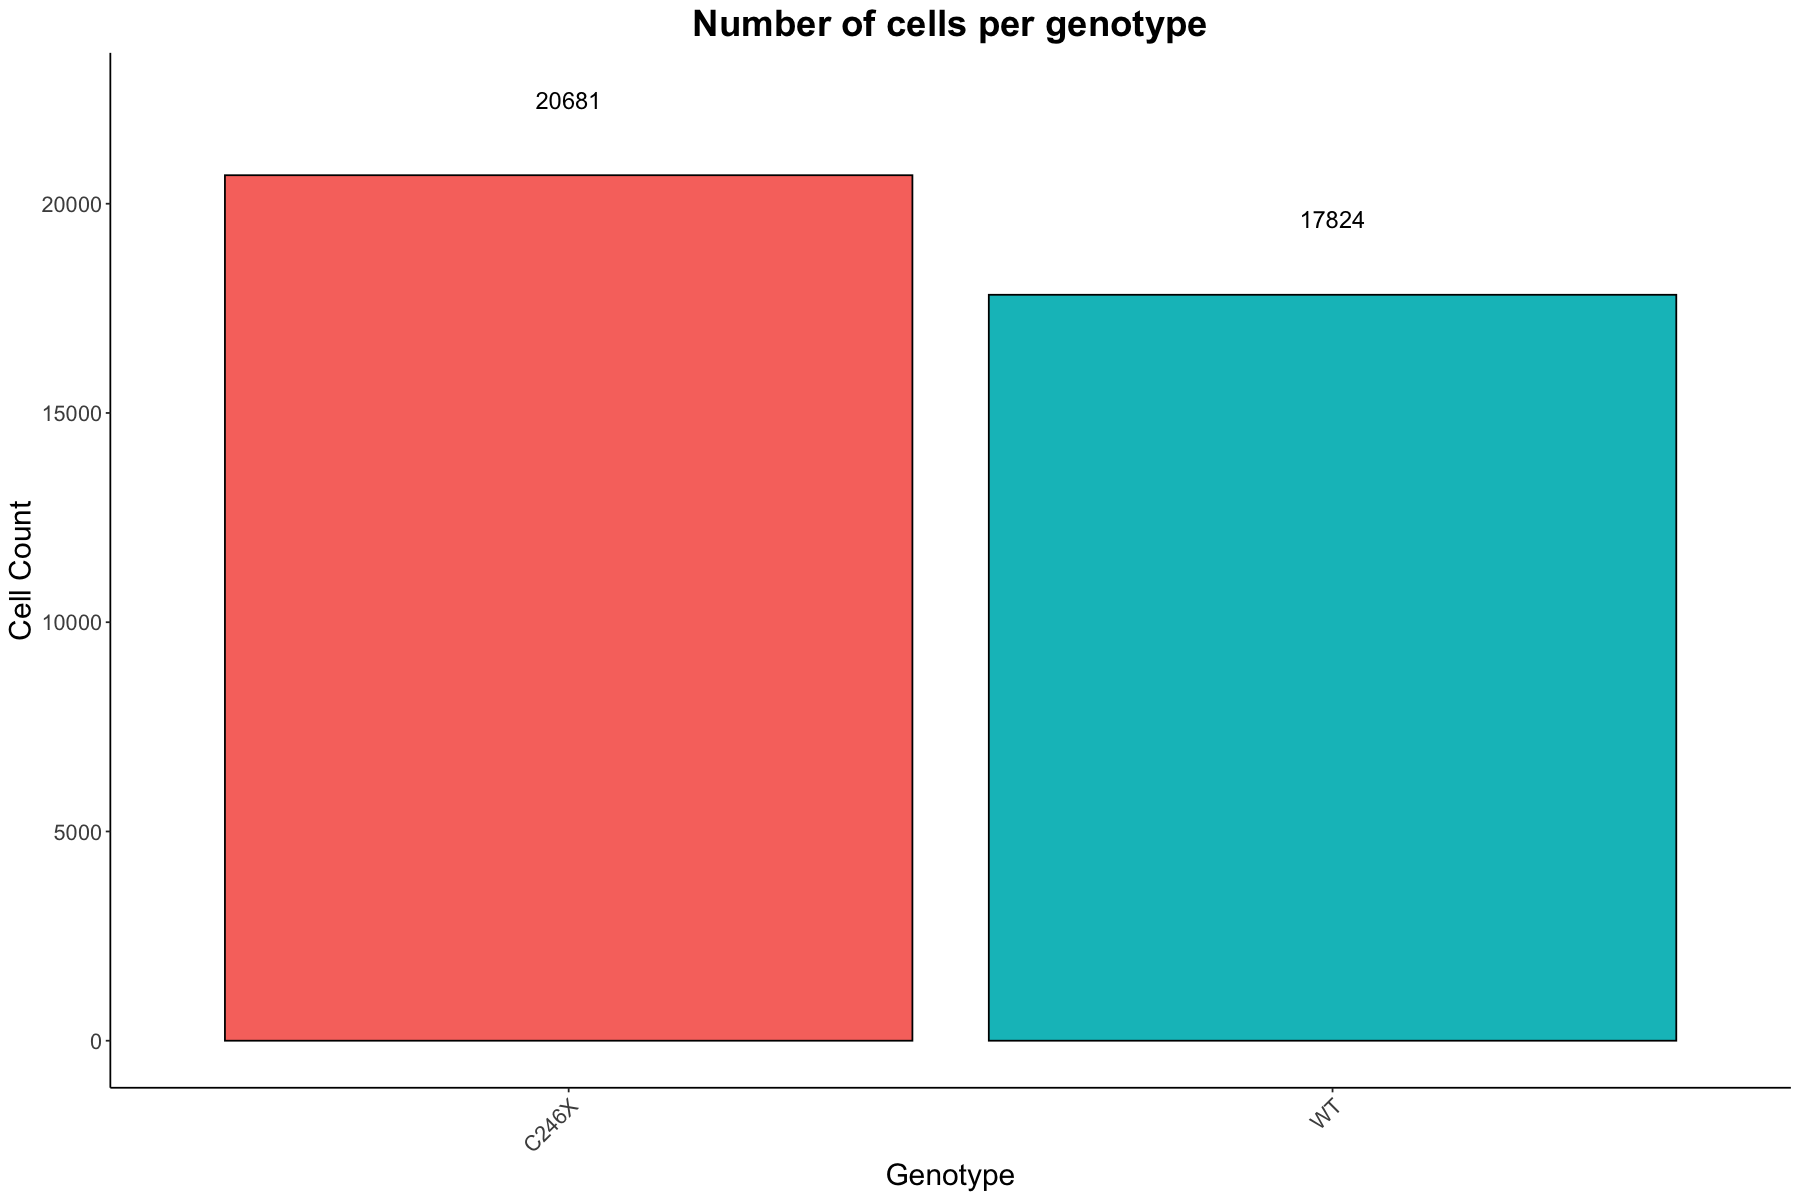

In [14]:
Unfilt_NOVOall_SRAT_metadata_final %>% 
  	ggplot(aes(x=genotype, fill=genotype)) + 
  	geom_bar(color = "black") +
    geom_text(aes(label = after_stat(count)), stat = "count", nudge_y = 1800, size = 5) +
  	theme_classic() +
  	theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
  	theme(plot.title = element_text(hjust=0.5, face="bold"), 
  	      legend.position = "none") +
    labs(x = "Genotype", y = "Cell Count") + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 22)) + 
  	ggtitle("Number of cells per genotype") 

# print total cell count 
print(dim(Unfilt_NOVOall_SRAT_metadata_final)[1])

## Visualize the number UMIs/transcript counts per cell

Low UMI indicates poor sequencing quality

In [15]:
x_intercept1 = as.numeric(readline(prompt = "Please enter a base UMI count: "))

Please enter a base UMI count:  500


### Per genotype

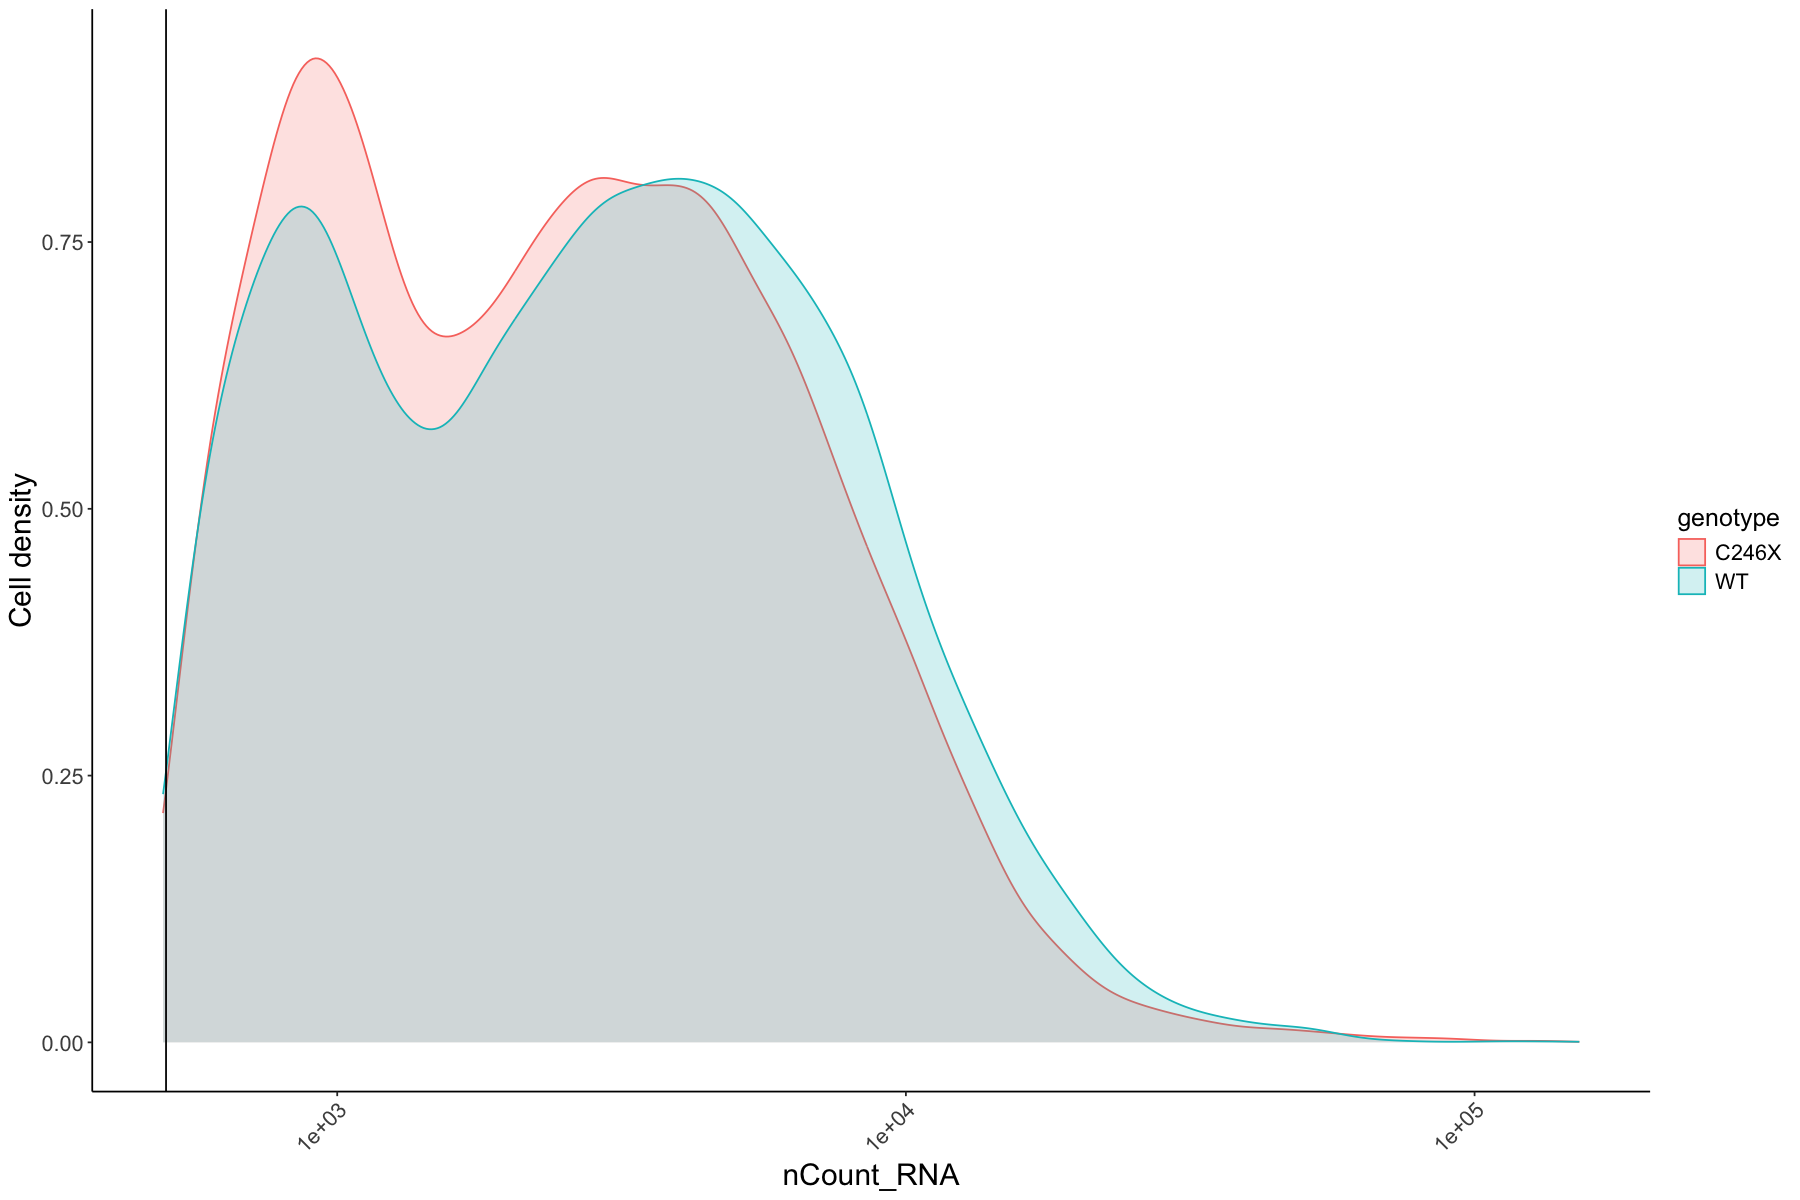

In [17]:
Unfilt_NOVOall_SRAT_metadata_final %>% 
  ggplot(aes(color = genotype, x = nCount_RNA, fill = genotype)) + 
  geom_density(alpha = 0.2) + 
  scale_x_log10() + 
  theme_classic() +
  ylab("Cell density") +
  geom_vline(xintercept = x_intercept1) + 
  theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15))

### Per sample

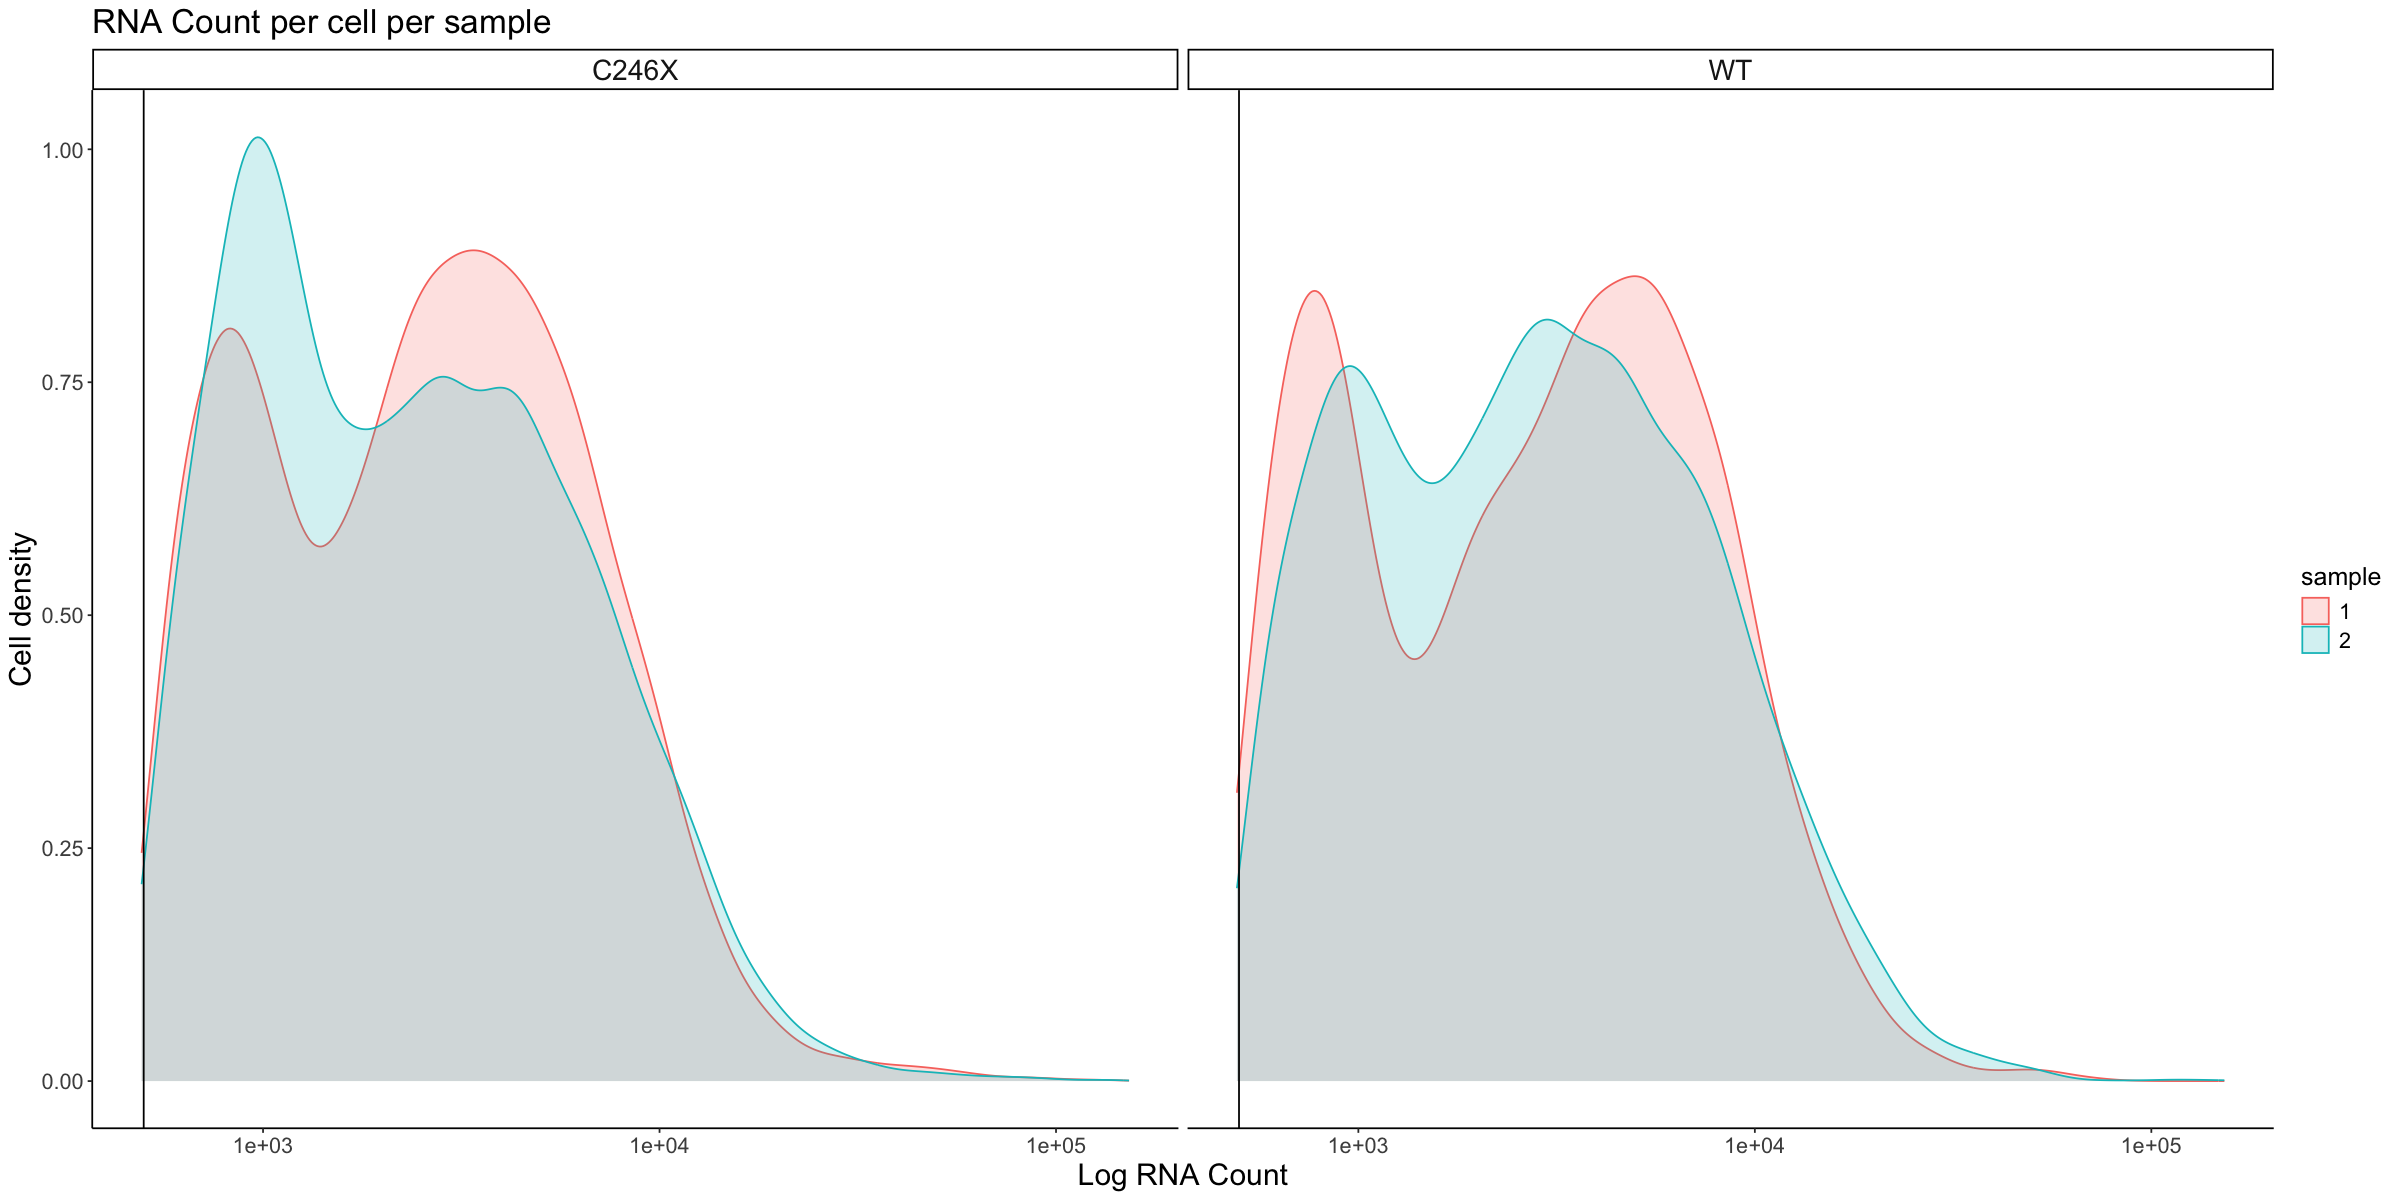

In [18]:
options(repr.plot.width=20, repr.plot.height=10)

Unfilt_NOVOall_SRAT_metadata_final %>% 
  ggplot(aes(color = sample, x = nCount_RNA, fill = sample)) + 
  geom_density(alpha = 0.2) +
  theme_classic() +
  scale_x_log10() + 
  ylab("Cell density") +
  geom_vline(xintercept = x_intercept1) + 
  labs(x = "Log RNA Count") + 
  ggtitle("RNA Count per cell per sample") + 
  facet_wrap(~genotype) + 
  theme(axis.text.x = element_text(size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 20),
          strip.text = element_text(size = 17)) # size of title for each facet

## Visualize the distribution of genes (features) detected per cell

"For high quality data, the proportional histogram should contain a single large peak that represents cells that were encapsulated. If we see a small shoulder to the right of the major peak (not present in our data), or a bimodal distribution of the cells, that can indicate a couple of things. It might be that there are a set of cells that failed for some reason. It could also be that there are biologically different types of cells (i.e. quiescent cell populations, less complex cells of interest), and/or one type is much smaller than the other (i.e. cells with high counts may be cells that are larger in size)."

In [19]:
x_intercept3 = as.numeric(readline(prompt = "Please enter a base featureRNA count: "))

Please enter a base featureRNA count:  300


### Per genotype

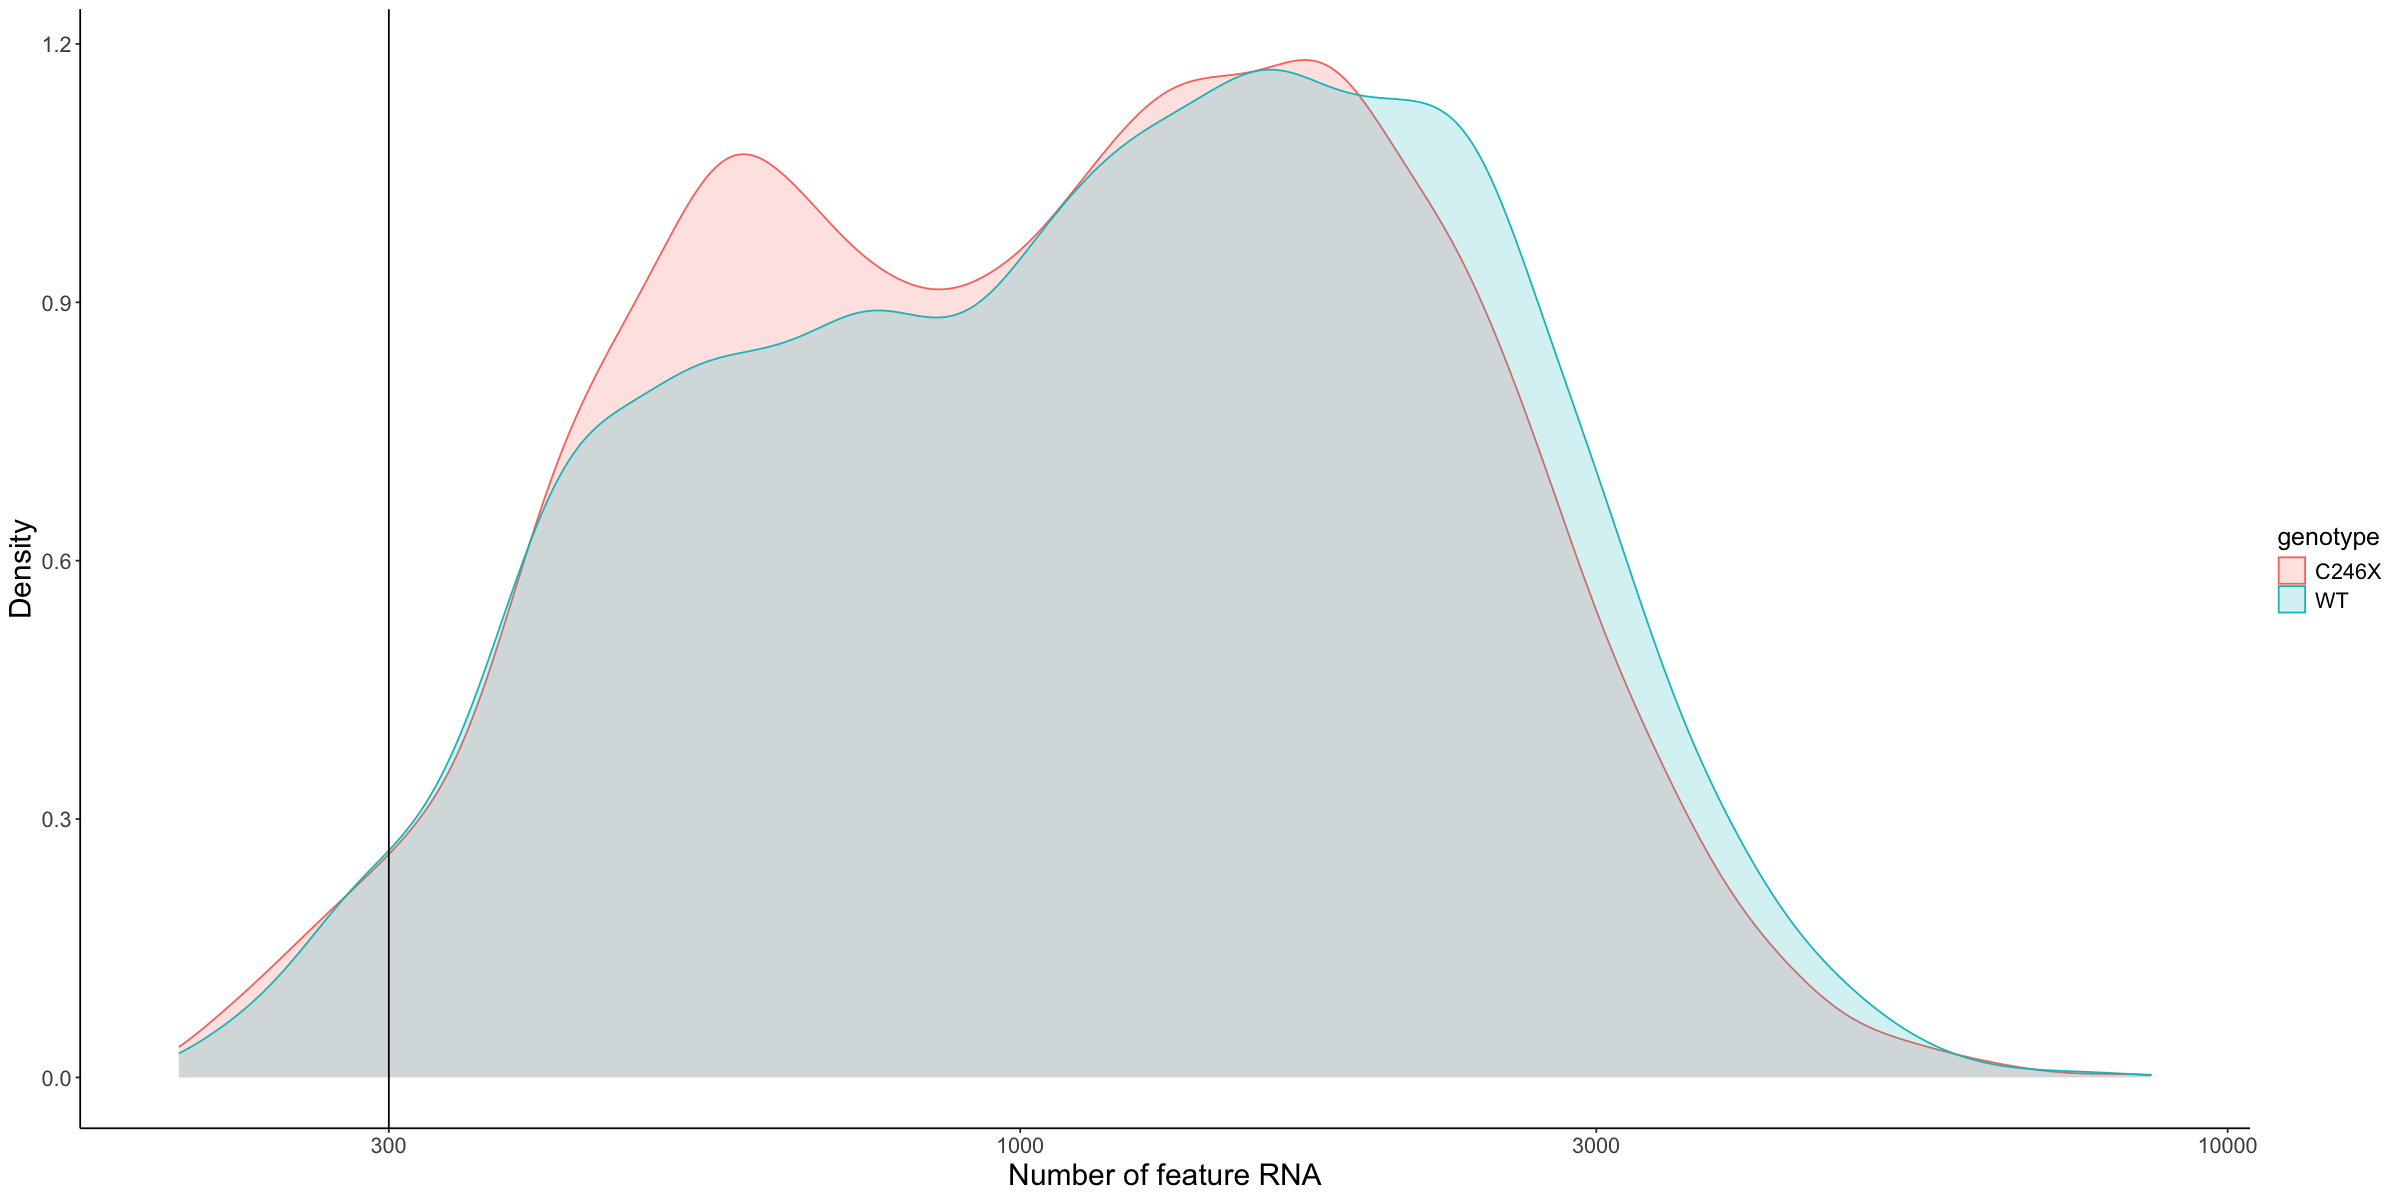

In [20]:
Unfilt_NOVOall_SRAT_metadata_final %>% 
  	ggplot(aes(color=genotype, x=nFeature_RNA, fill= genotype)) + 
  	geom_density(alpha = 0.2) + 
  	theme_classic() +
  	scale_x_log10() + 
    labs(x = "Number of feature RNA", y = "Density") + 
  	geom_vline(xintercept = x_intercept3) + 
    theme(axis.text.x = element_text(size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 20),
          strip.text = element_text(size = 17))

### Per sample

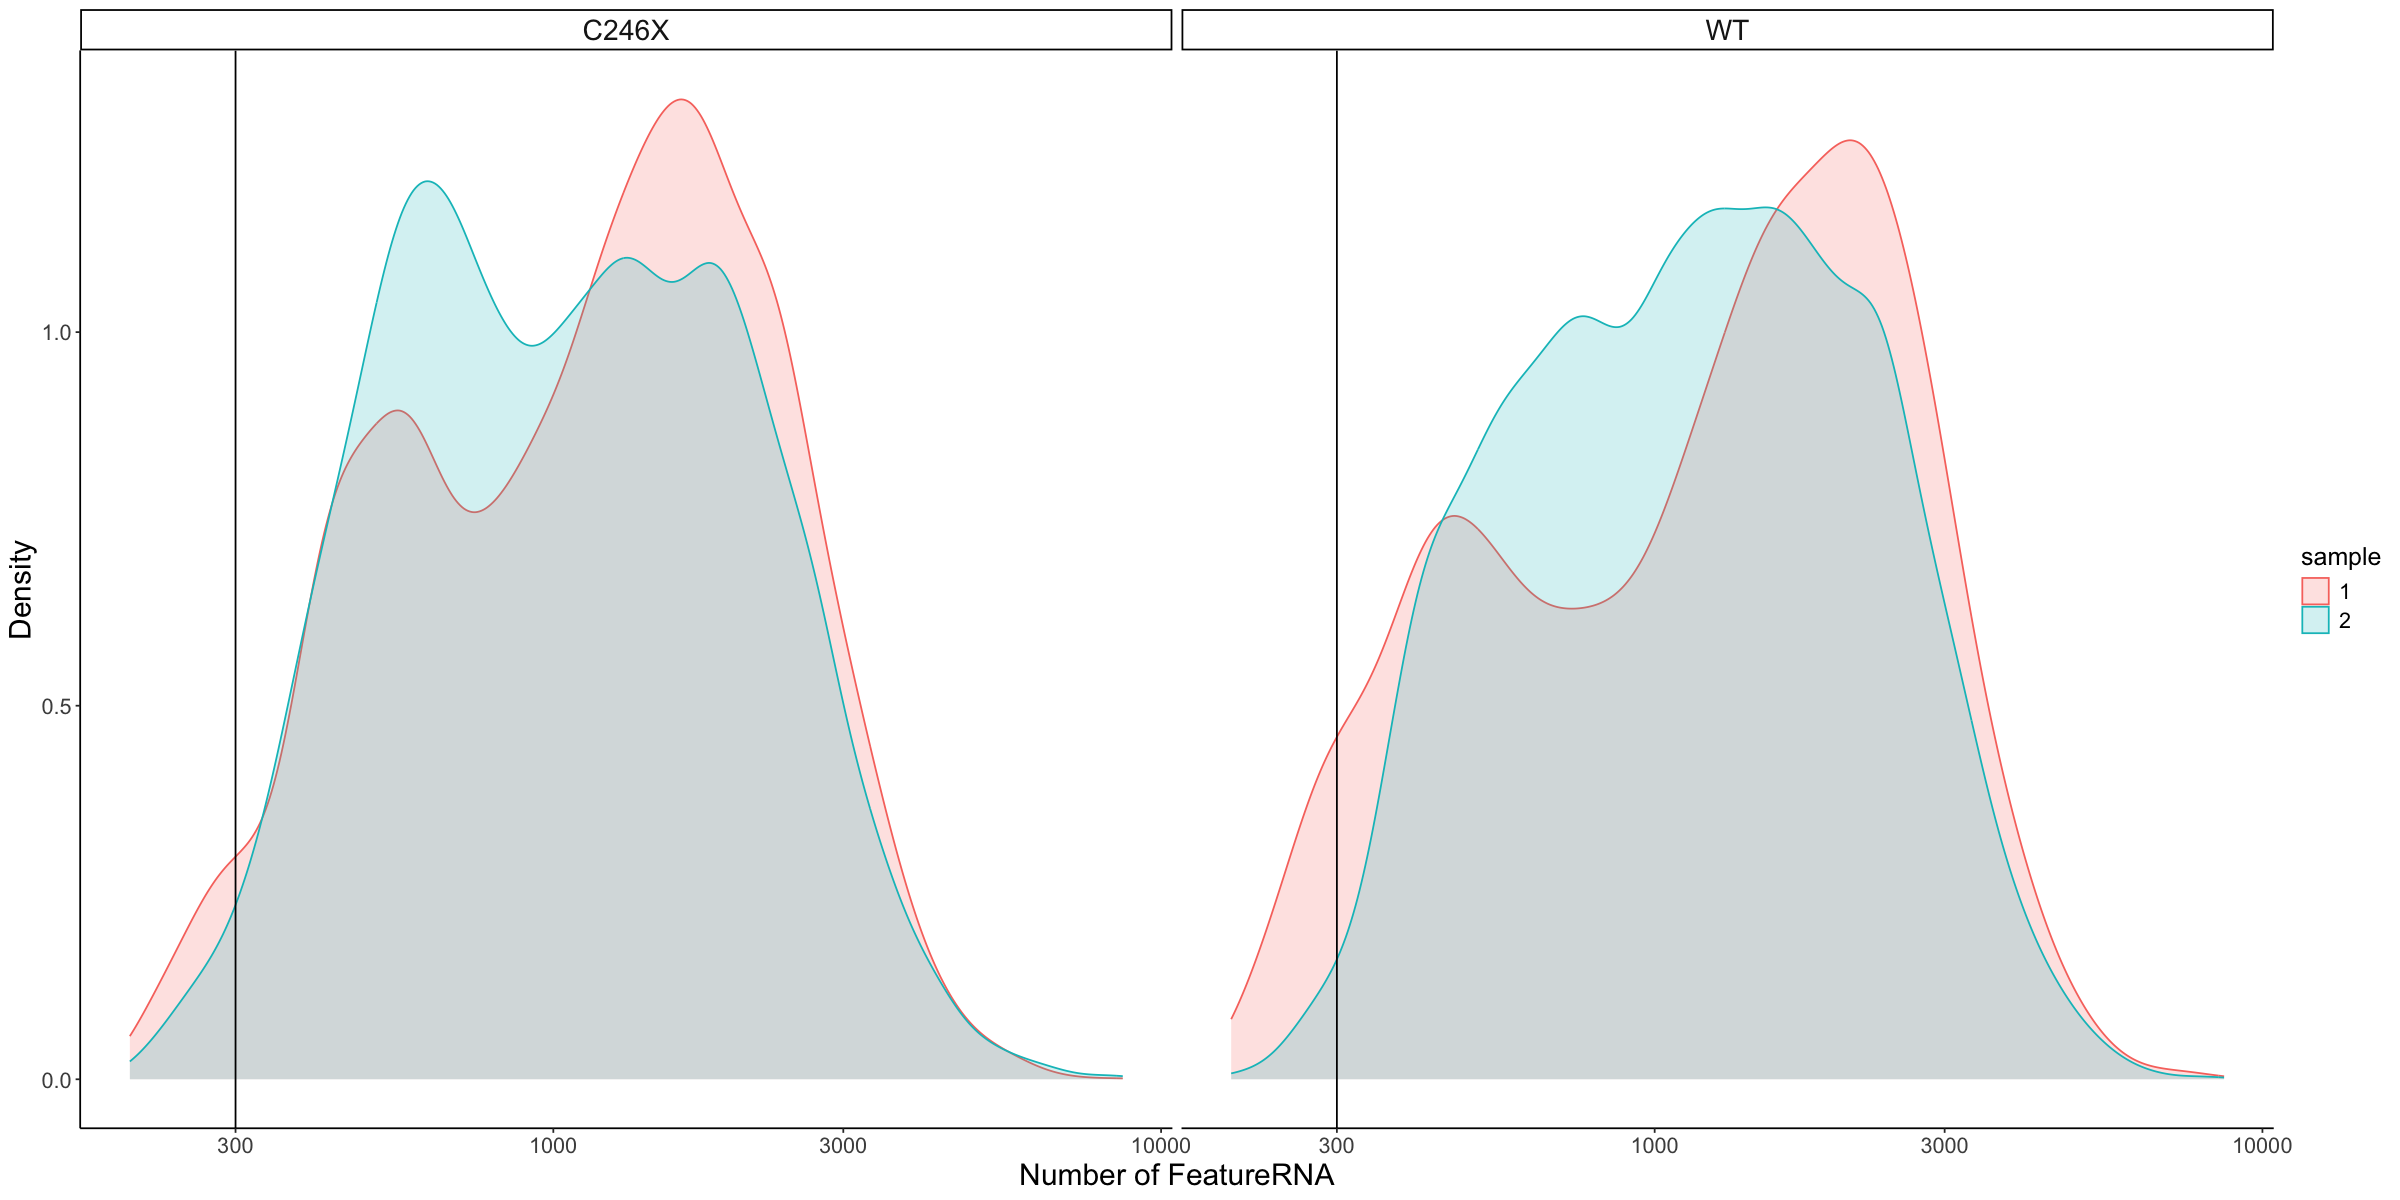

In [21]:
Unfilt_NOVOall_SRAT_metadata_final %>% 
  	ggplot(aes(color=sample, x=nFeature_RNA, fill= sample)) + 
  	geom_density(alpha = 0.2) + 
  	theme_classic() +
  	scale_x_log10() + 
    labs(x = "Number of FeatureRNA", y = "Density") + 
  	geom_vline(xintercept = x_intercept3) + 
    theme(axis.text.x = element_text(size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 20),
          strip.text = element_text(size = 17)) + 
    facet_wrap(~genotype)

## Visualize the correlation between genes detected and number of UMIs

Determine whether strong presence of cells with low numbers of genes/UMIs

"Cells that are poor quality are likely to have low genes and UMIs per cell, and correspond to the data points in the bottom left quadrant of the plot. Good cells will generally exhibit both higher number of genes per cell and higher numbers of UMIs

With this plot we also evaluate the slope of the line, and any scatter of data points in the bottom right hand quadrant of the plot. These cells have a high number of UMIs but only a few number of genes. These could be dying cells, but also could represent a population of a low complexity celltype (i.e red blood cells)."

In [22]:
x_int4 = as.numeric(readline(prompt = "Please enter RNA Count: ")) # 500 
y_int1 = as.numeric(readline(prompt = "Please enter Feature RNA: ")) # 500

Please enter RNA Count:  500
Please enter Feature RNA:  500


`geom_smooth()` using formula = 'y ~ x'


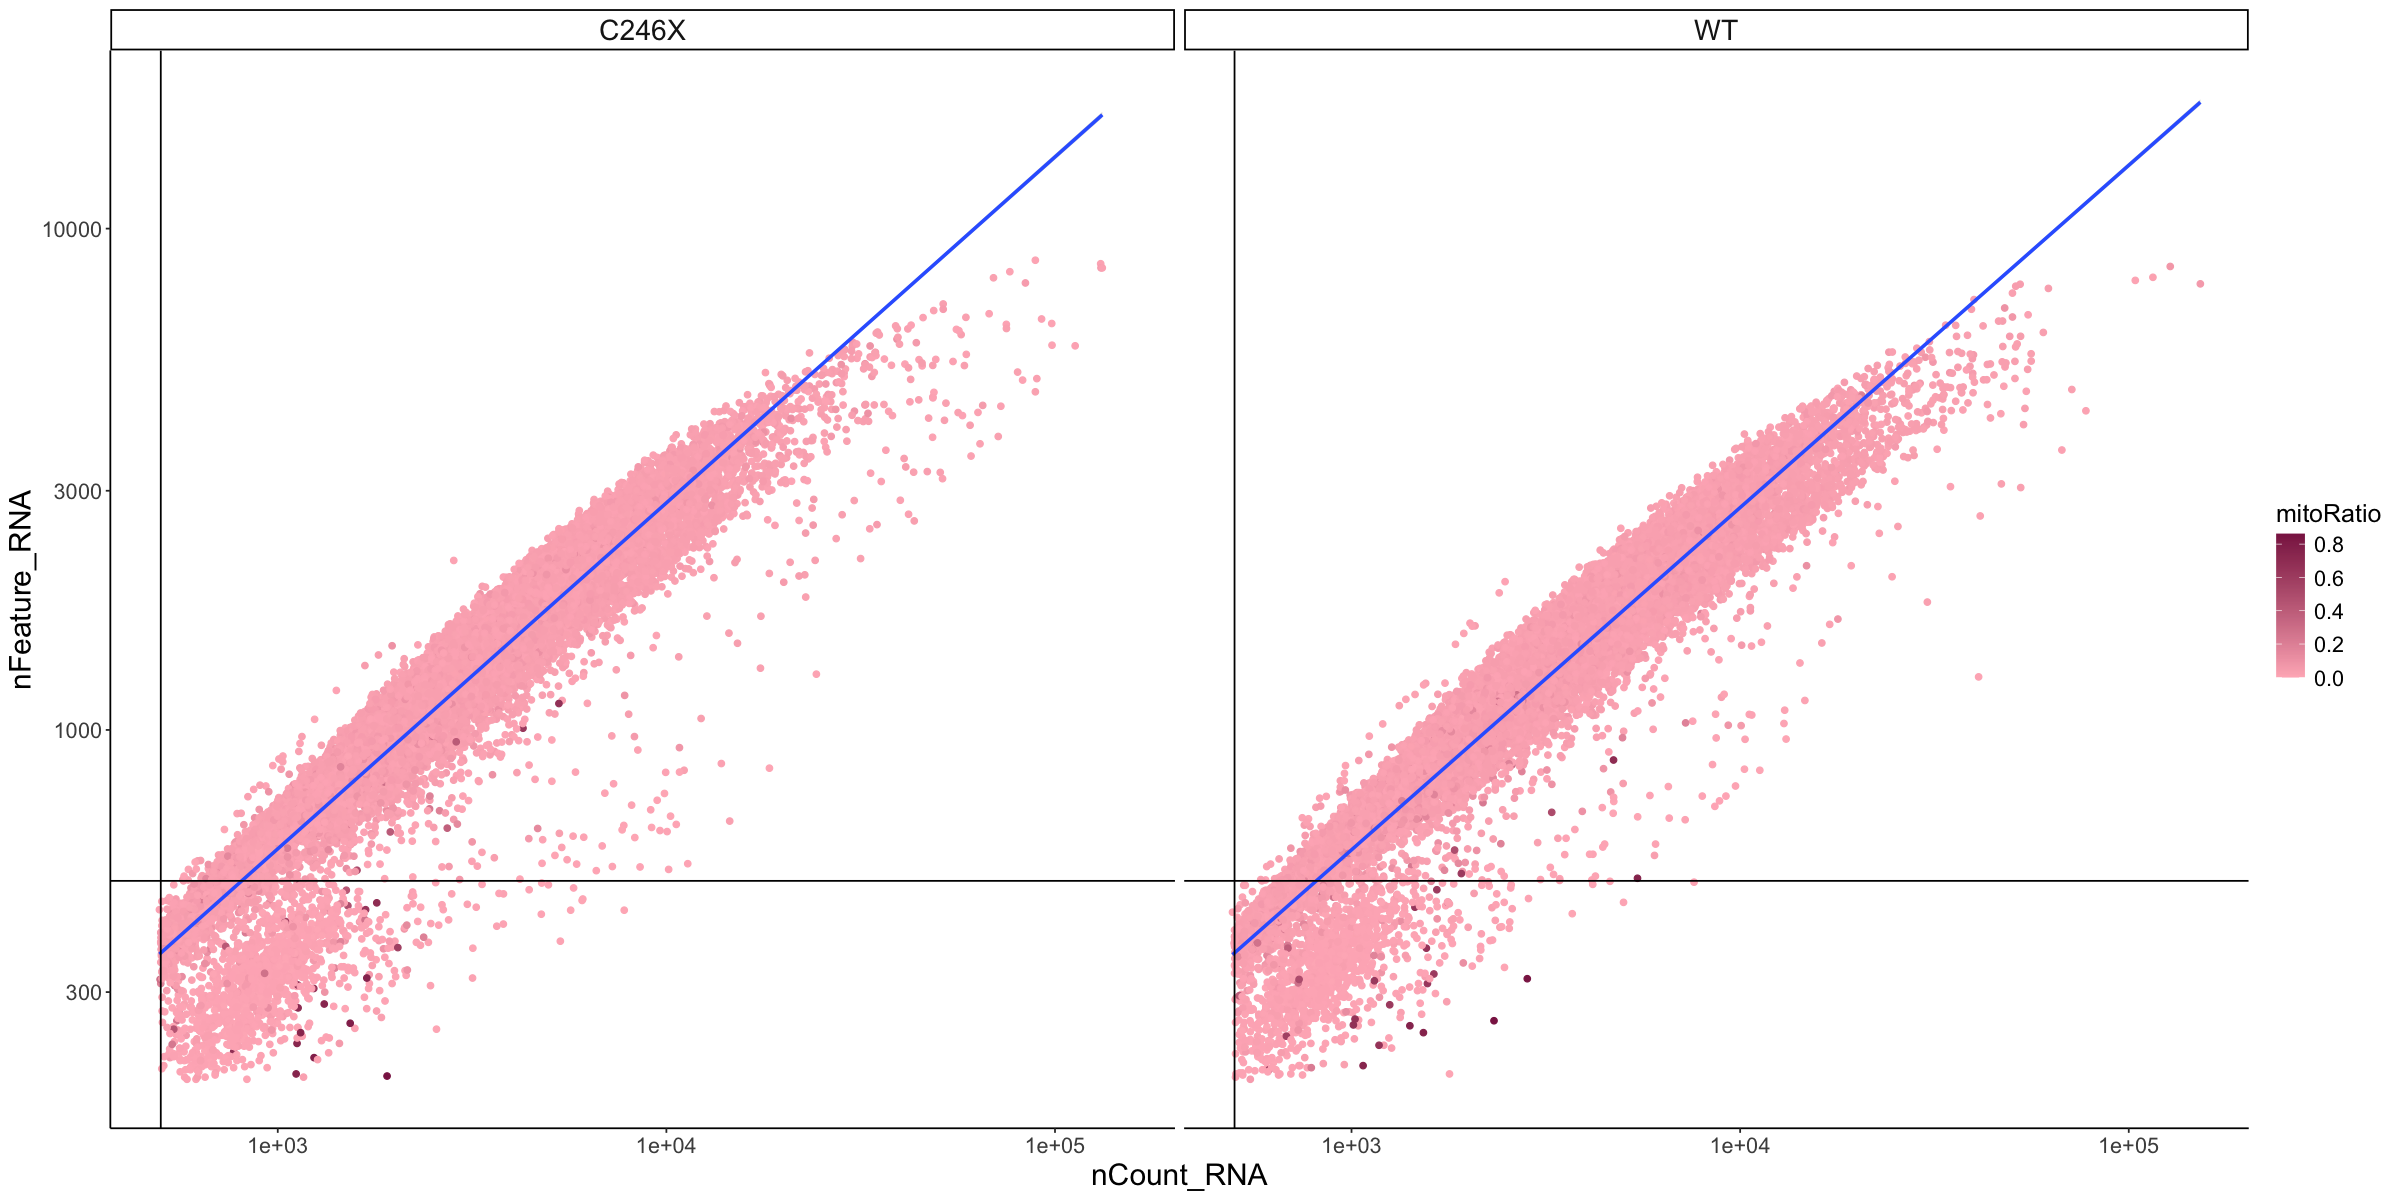

In [23]:
Unfilt_NOVOall_SRAT_metadata_final %>% 
  	ggplot(aes(x=nCount_RNA, y=nFeature_RNA)) + 
  	geom_point(aes(color=mitoRatio)) + 
	scale_colour_gradient(low = "lightpink", high = "violetred4") +
  	stat_smooth(method=lm) +
  	scale_x_log10() + 
  	scale_y_log10() + 
  	theme_classic() +
  	geom_vline(xintercept = x_int4) +
  	geom_hline(yintercept = y_int1) +
  	facet_wrap(~genotype) + 
    theme(axis.text.x = element_text(size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 20),
          strip.text = element_text(size = 17))


The following plot is similar to the line plot above. We visualize the complexity of the gene expression by visualizing the genes detected per UMI

"We can see the samples where we sequenced each cell less have a higher overall complexity, that is because we have not started saturating the sequencing for any given gene for these samples. Outlier cells in these samples might be cells that have a less complex RNA species than other cells. Sometimes we can detect contamination with low complexity cell types like red blood cells via this metric. Generally, we expect the novelty score to be above 0.80."

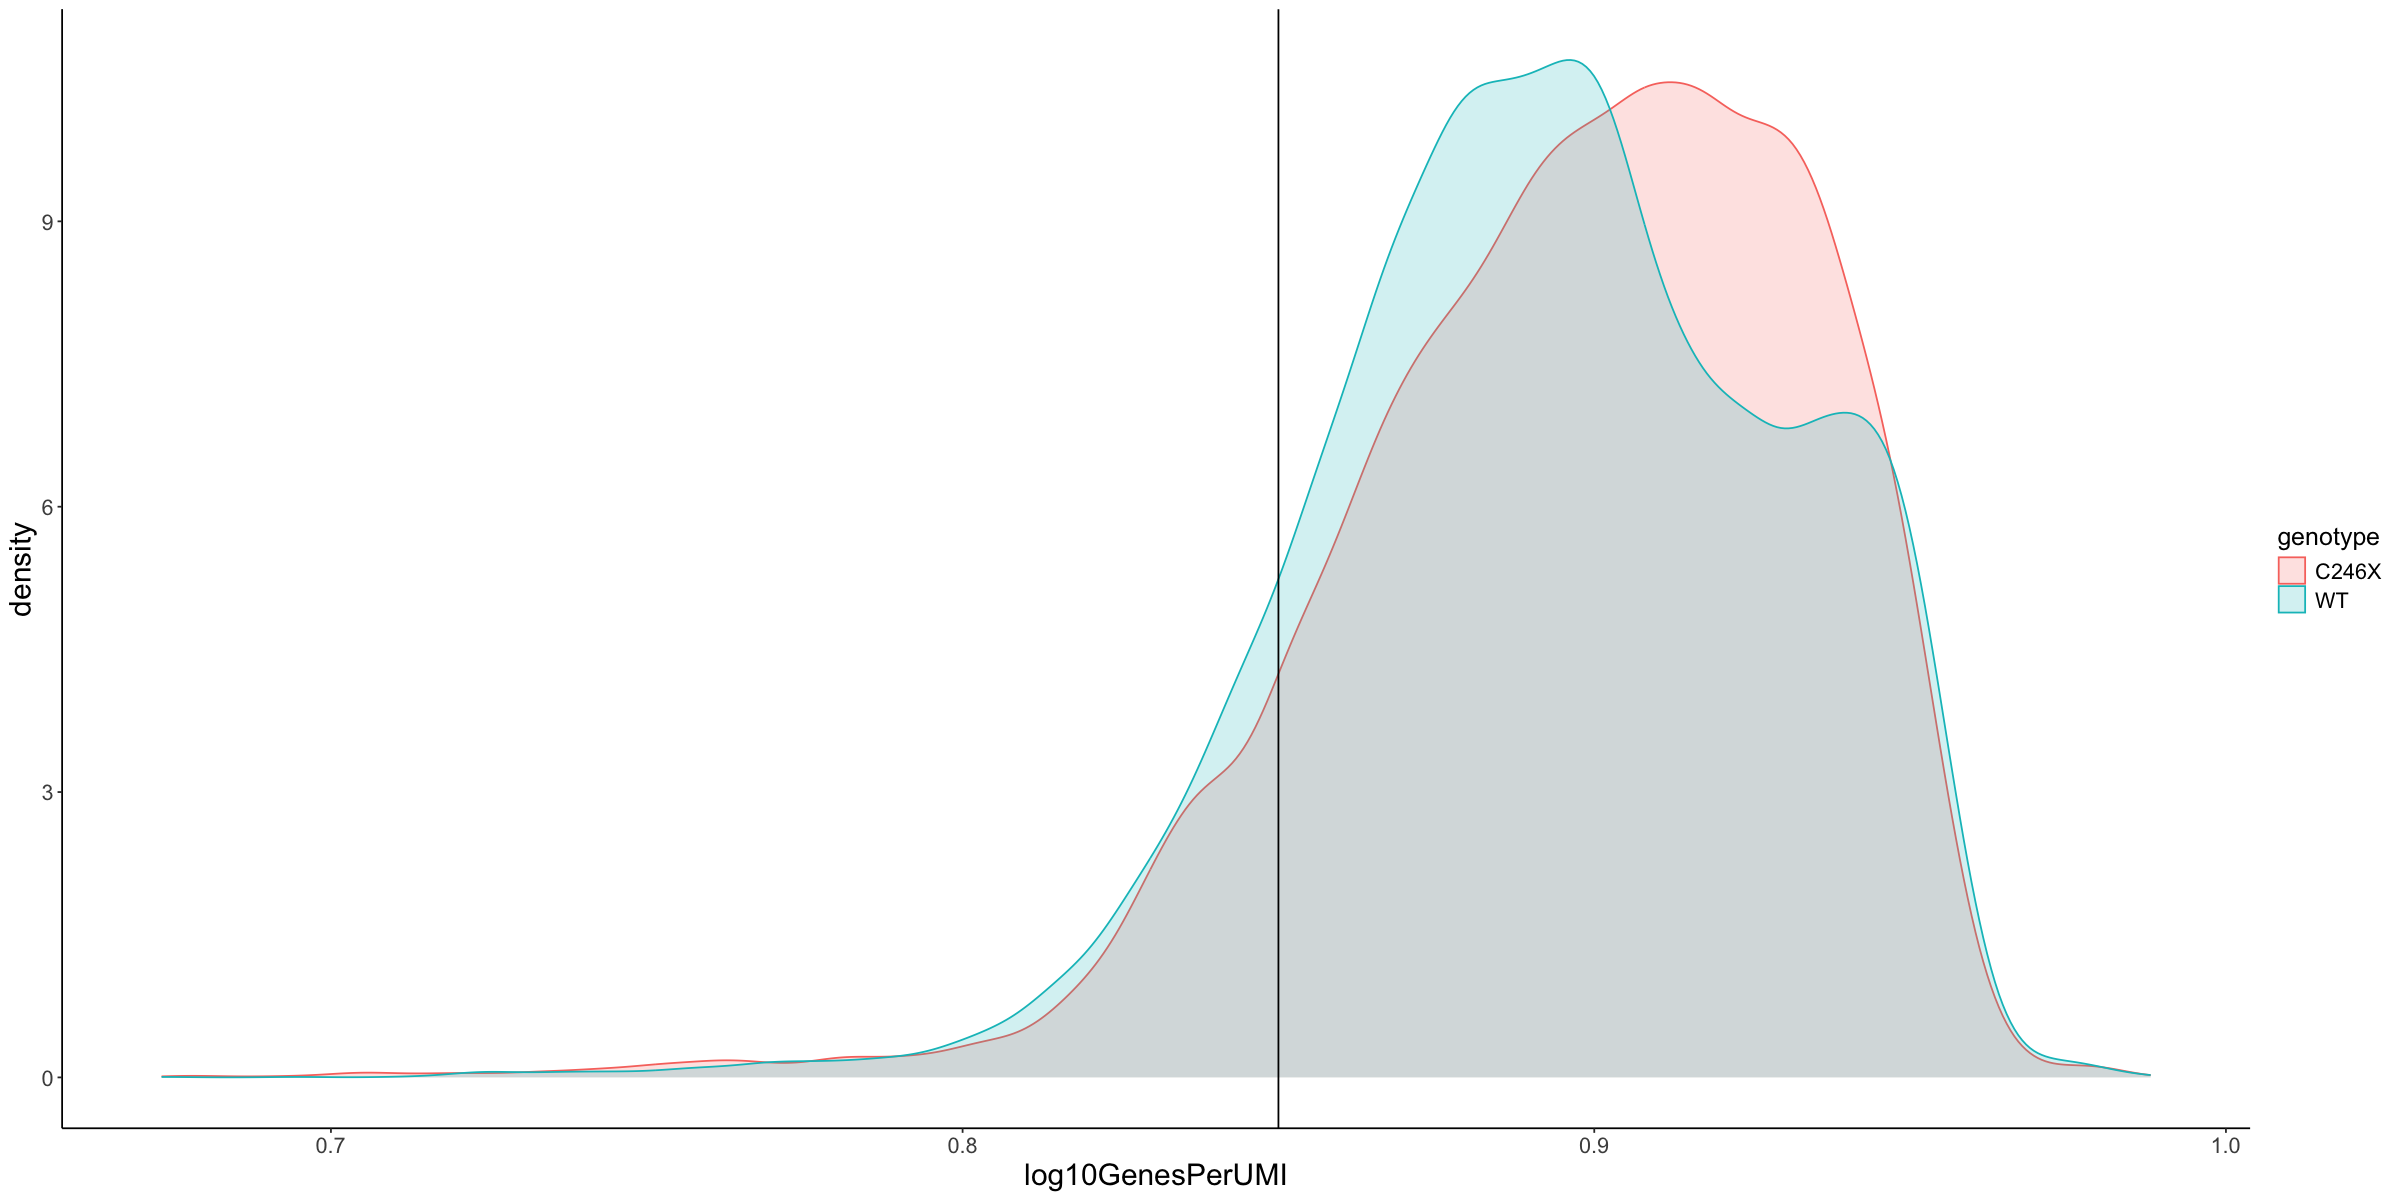

In [24]:
Unfilt_NOVOall_SRAT_metadata_final %>%
  	ggplot(aes(x=log10GenesPerUMI, color = genotype, fill=genotype)) +
  	geom_density(alpha = 0.2) +
  	theme_classic() +
  	geom_vline(xintercept = 0.85) + 
    theme(axis.text.x = element_text(size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 20),
          strip.text = element_text(size = 17))

## Visualize the distribution of mitochondrial gene expression detected per cell

"This metric can identify whether there is a large amount of mitochondrial contamination from dead or dying cells. We define poor quality samples for mitochondrial counts as cells which surpass the 0.2 mitochondrial ratio mark, unless of course you are expecting this in your sample."

In [25]:
x_int5 = as.numeric(readline(prompt = "Please enter a cut-off value for mito ratio: "))

Please enter a cut-off value for mito ratio:  0.1


Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 35 rows containing non-finite outside the scale range
(`stat_density()`).”


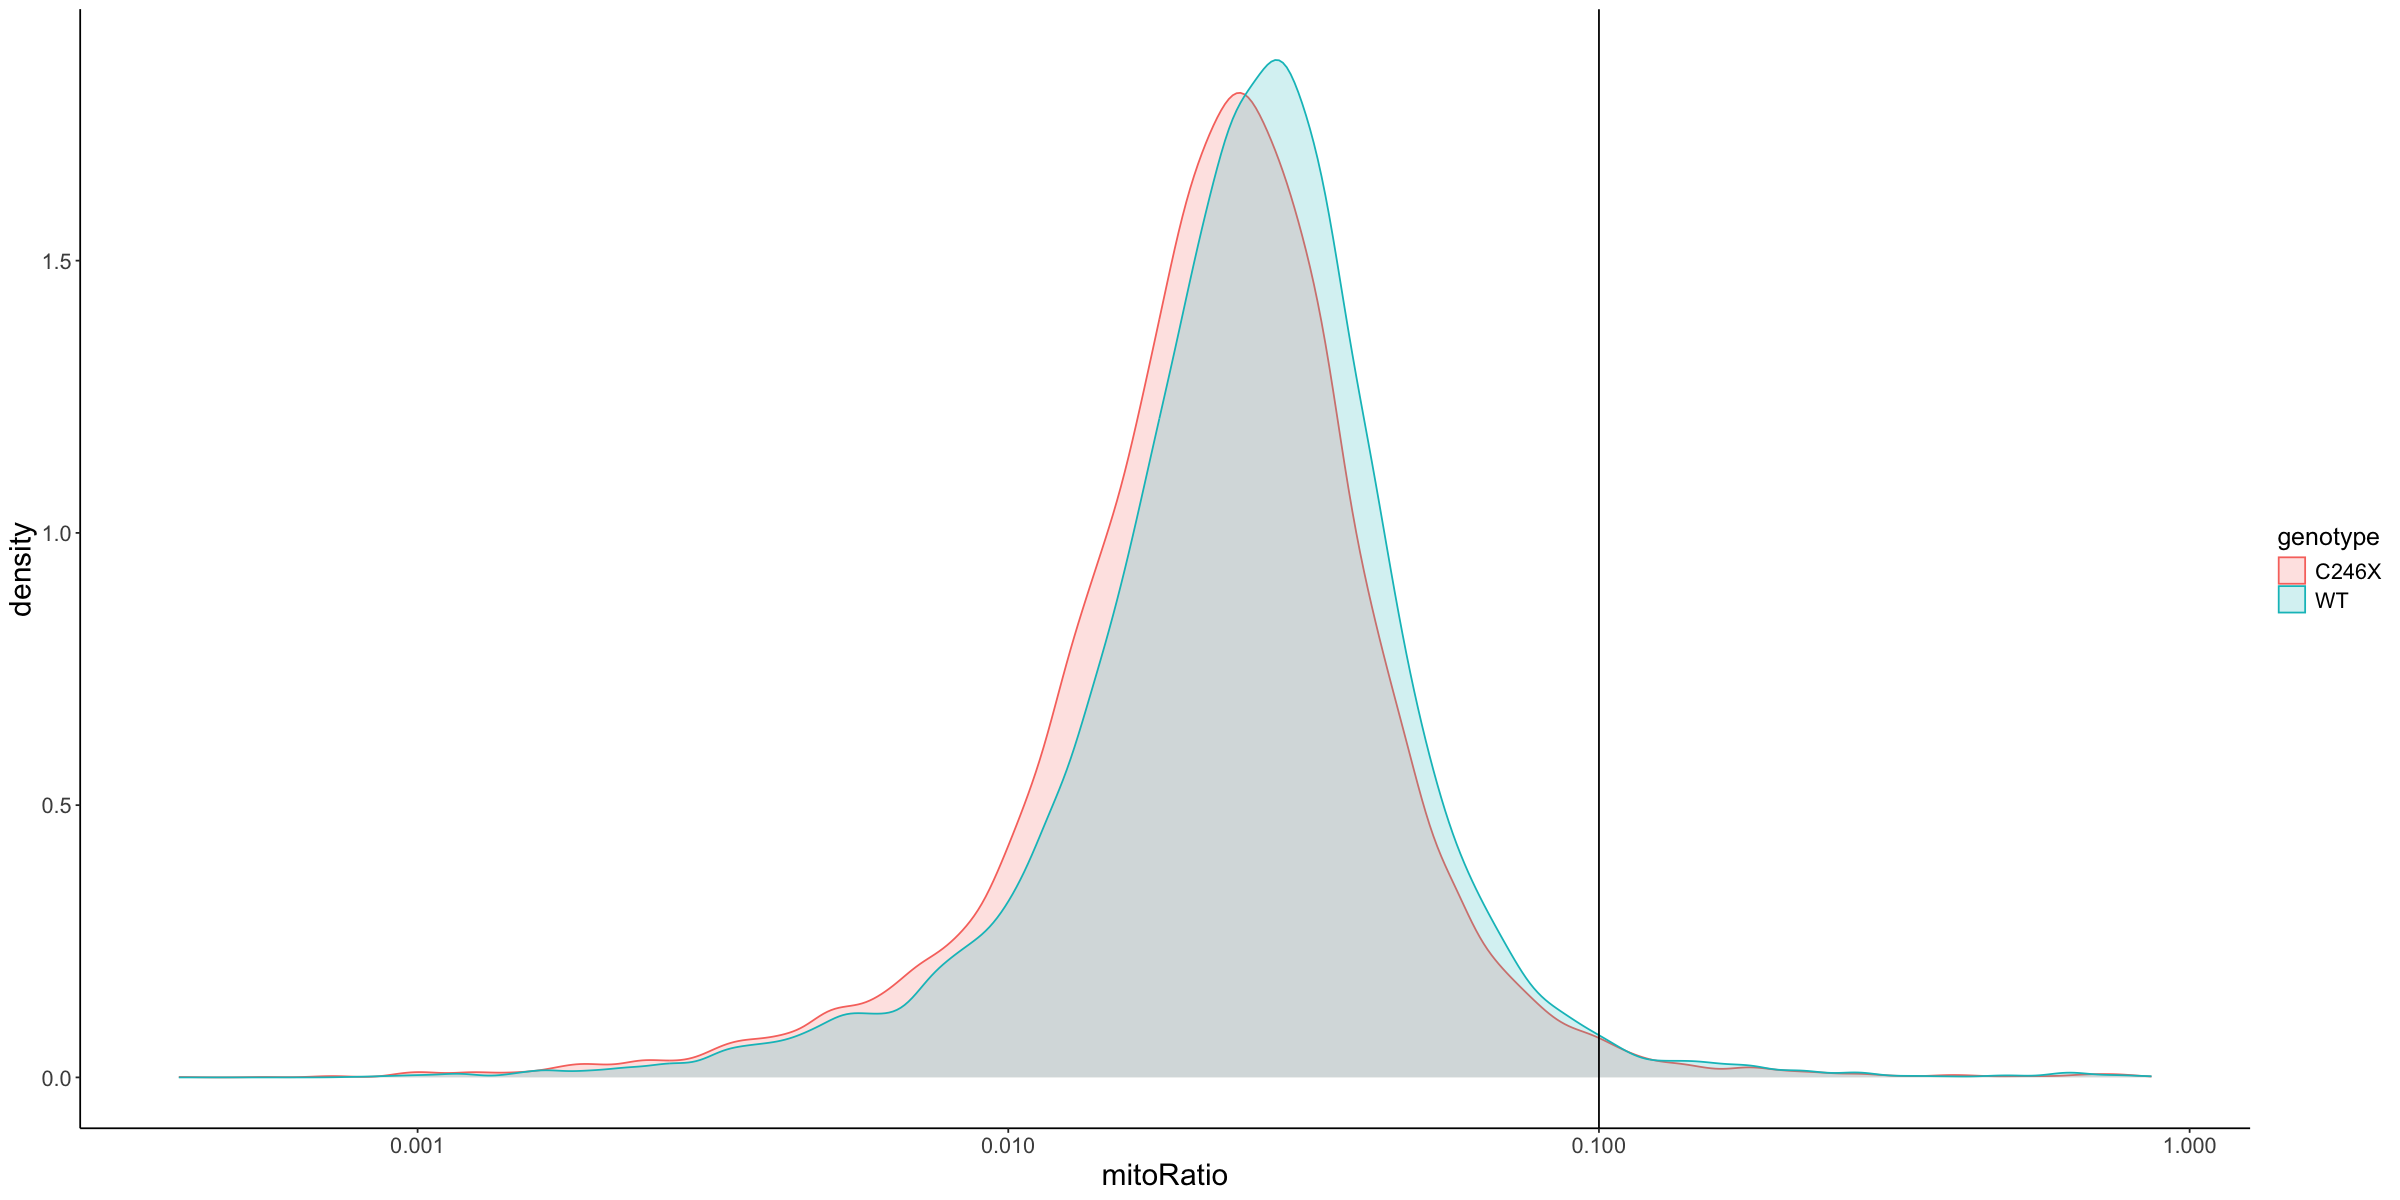

In [26]:
Unfilt_NOVOall_SRAT_metadata_final %>% 
  	ggplot(aes(color=genotype, x=mitoRatio, fill=genotype)) + 
  	geom_density(alpha = 0.2) + 
  	scale_x_log10() + 
  	theme_classic() +
  	geom_vline(xintercept = x_int5) + 
    theme(axis.text.x = element_text(size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 20),
          strip.text = element_text(size = 17))

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 35 rows containing non-finite outside the scale range
(`stat_density()`).”


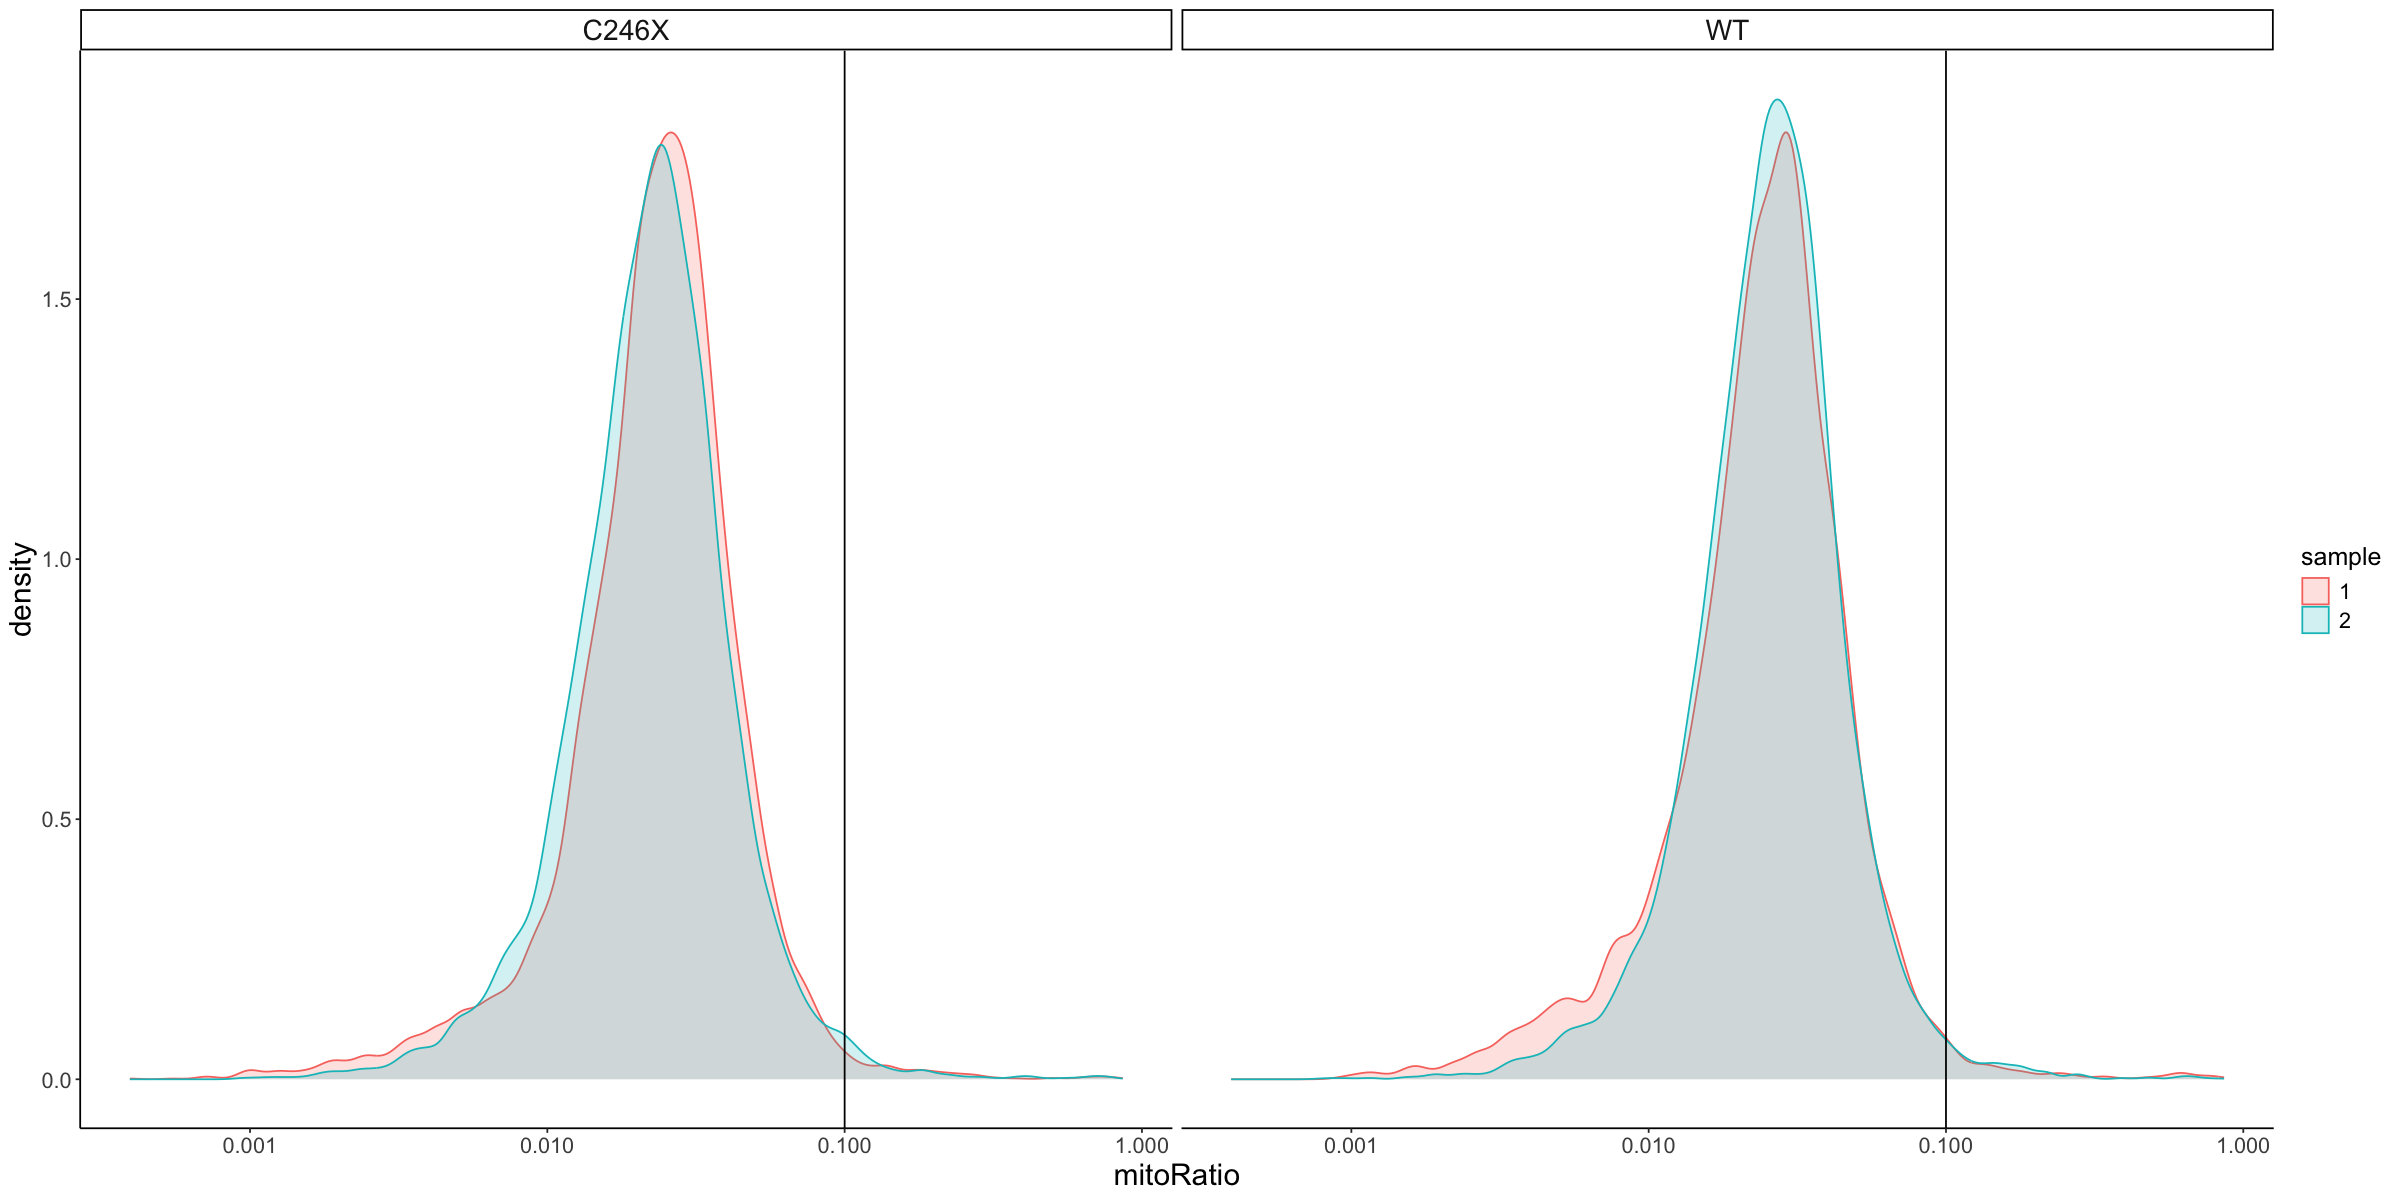

In [27]:
Unfilt_NOVOall_SRAT_metadata_final %>% 
  	ggplot(aes(color=sample, x=mitoRatio, fill=sample)) + 
  	geom_density(alpha = 0.2) + 
  	scale_x_log10() + 
  	theme_classic() +
  	geom_vline(xintercept = x_int5) + 
    theme(axis.text.x = element_text(size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 20),
          strip.text = element_text(size = 17)) + 
    facet_wrap(~genotype)

## QC step visualisation

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


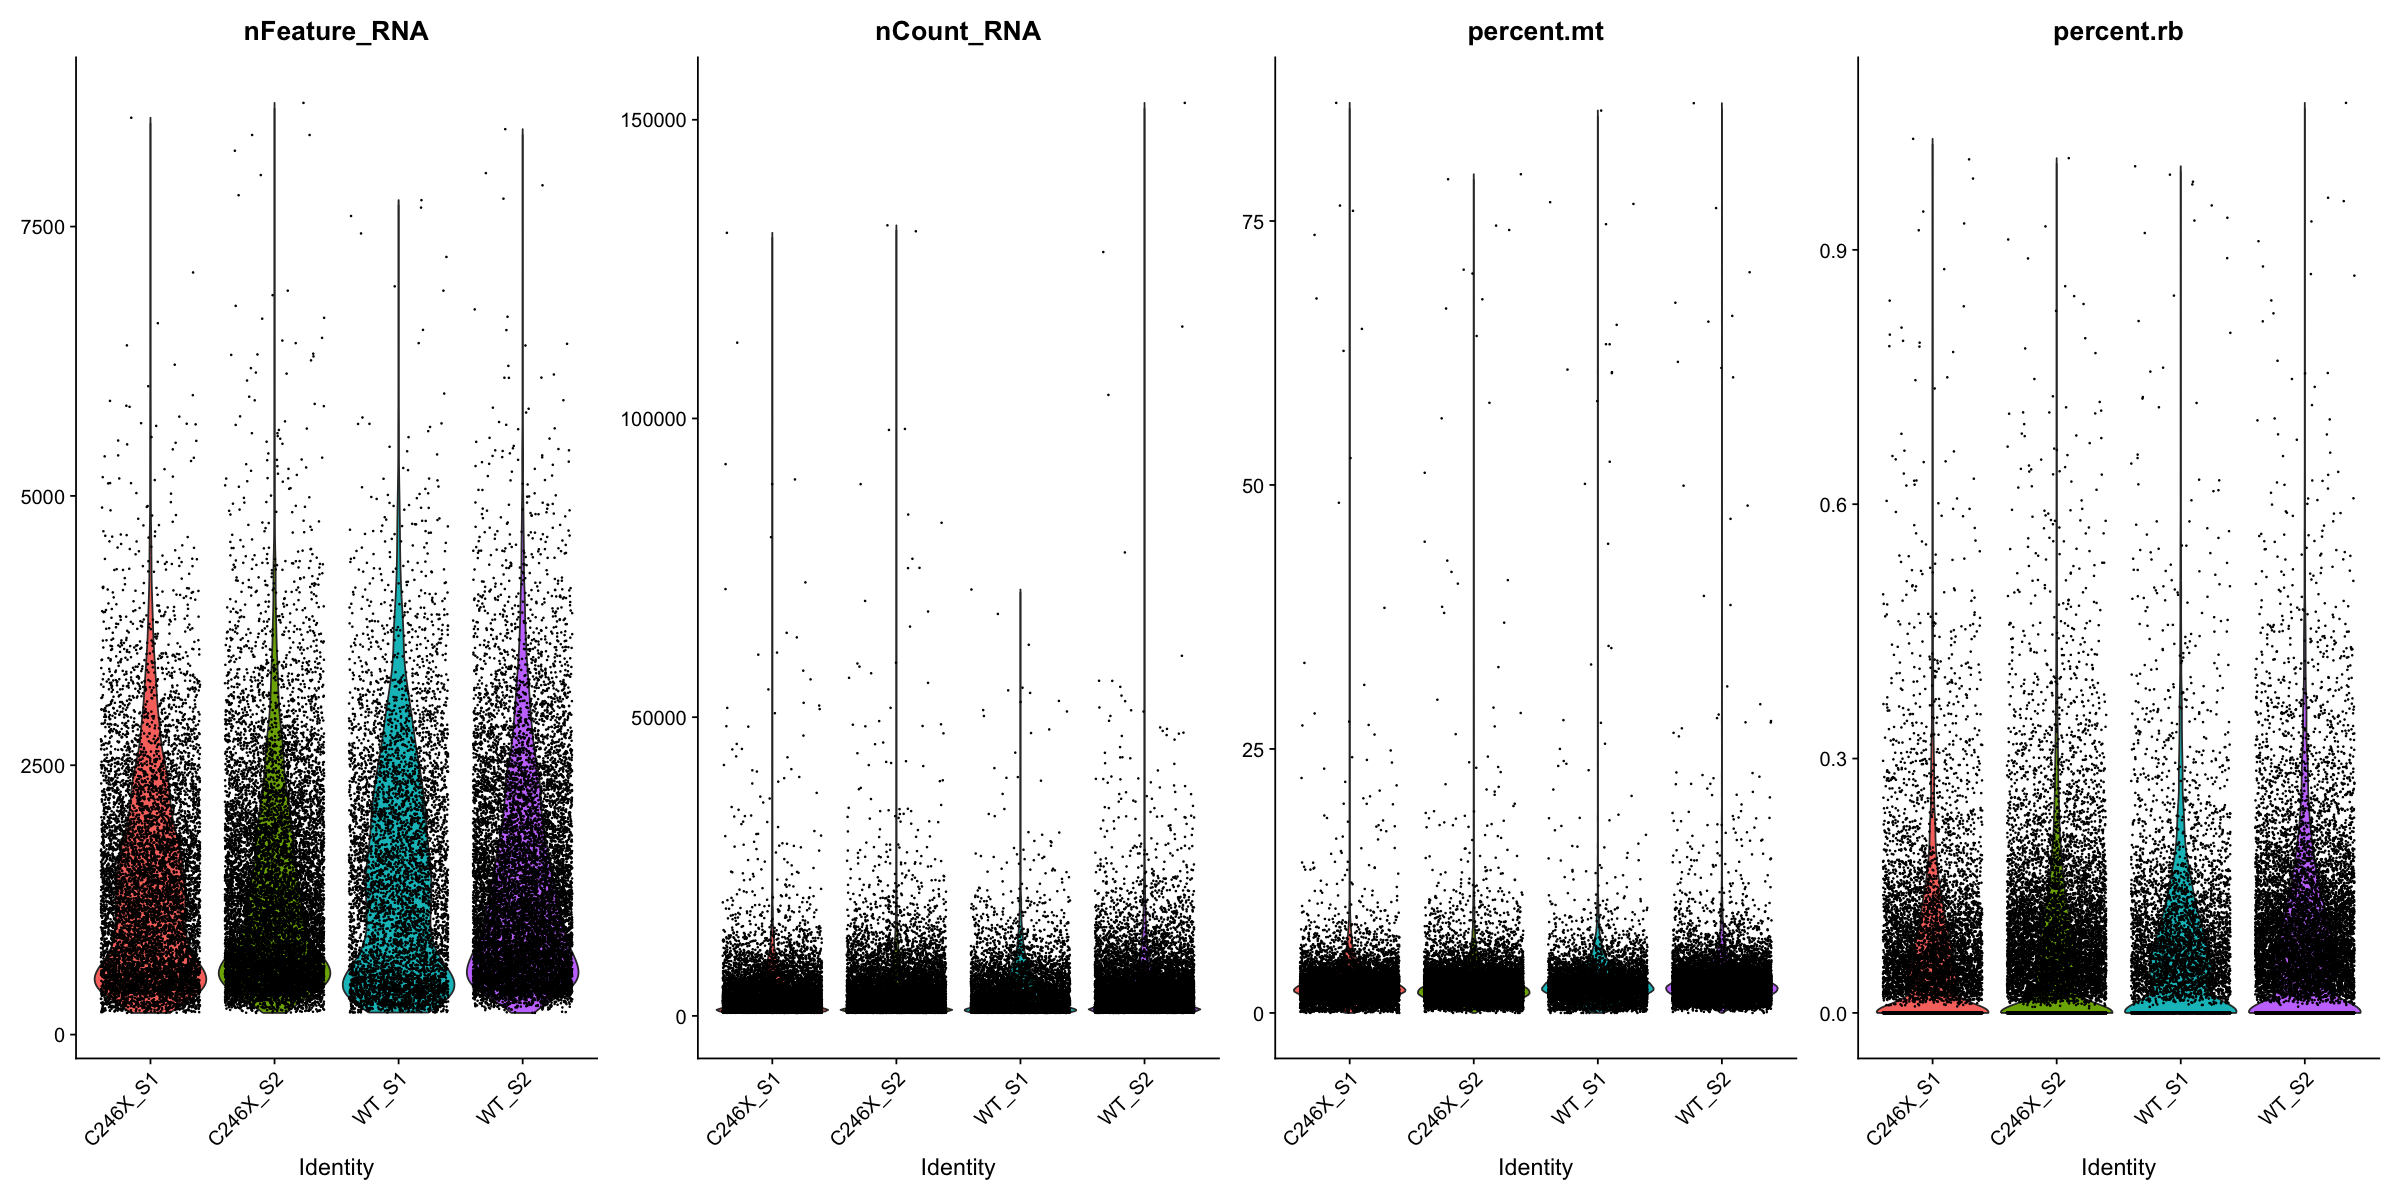

In [35]:
# Visualize QC metrics as a violin plot
VlnPlot(Unfilt_NOVOall_SRAT, features = c("nFeature_RNA", "nCount_RNA", "percent.mt", "percent.rb"), group.by = "orig.ident", ncol = 4, raster=FALSE)

## Plot counts vs mitochondrial counts and counts vs features

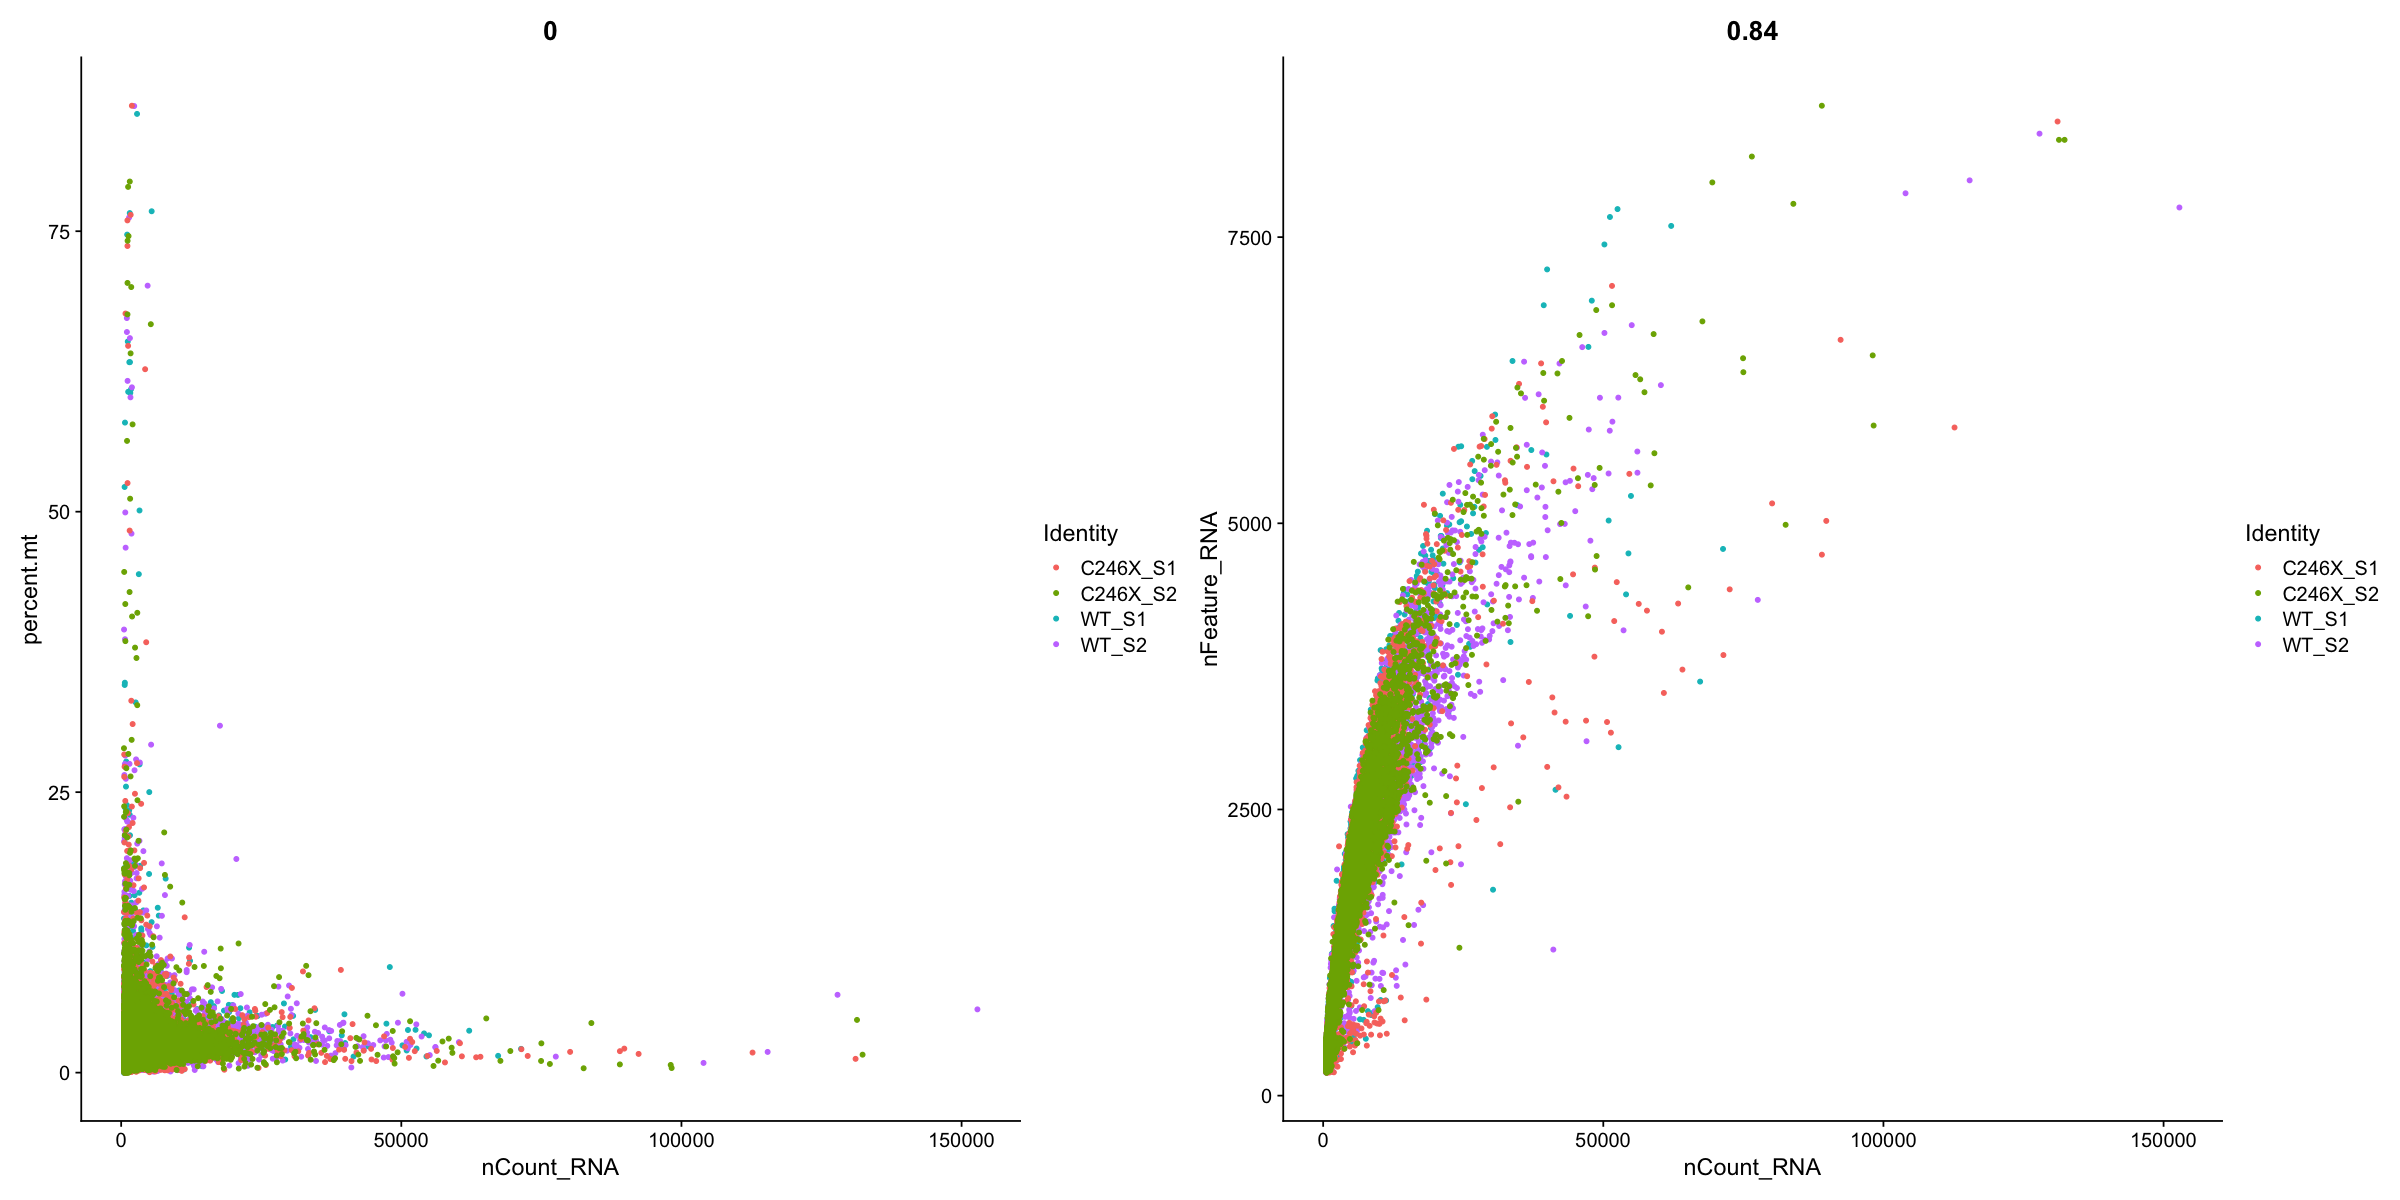

In [36]:
plot1 <- FeatureScatter(Unfilt_NOVOall_SRAT, feature1 = "nCount_RNA", feature2 = "percent.mt", group.by = "orig.ident")
plot2 <- FeatureScatter(Unfilt_NOVOall_SRAT, feature1 = "nCount_RNA", feature2 = "nFeature_RNA", group.by = "orig.ident")
plot1 + plot2

## ***Filter the data*** 

## Filter out low quality using selected thresholds

In [37]:
RNA_count_LB = as.numeric(readline(prompt = "Please enter a lower bound for RNA count: ")) # lower bound for RNA count (500)
RNA_count_UP = as.numeric(readline(prompt = "Please enter an upper bound for RNA count: ")) # 10000
feature_RNA = as.numeric(readline(prompt = "Please enter a feature RNA cutoff value: ")) # 300
log10genesPerUMI = as.numeric(readline(prompt = "Please enter a log10genesPerUMI cutoff value: ")) # 0.85
percent_mt = as.numeric(readline(prompt = "Please enter a mito percent cutoff value: ")) # 7.5
mitoratio = as.numeric(readline(prompt = "Please enter a mitoratio cutoff value: ")) # 0.1

Please enter a lower bound for RNA count:  500
Please enter an upper bound for RNA count:  10000
Please enter a feature RNA cutoff value:  300
Please enter a log10genesPerUMI cutoff value:  0.85
Please enter a mito percent cutoff value:  7.5
Please enter a mitoratio cutoff value:  0.1


In [41]:
Filt_1_NOVOall_SRAT <- subset(x = Unfilt_NOVOall_SRAT, 
                         subset= ( Unfilt_NOVOall_SRAT$nCount_RNA>= RNA_count_LB) &
                           (Unfilt_NOVOall_SRAT$nCount_RNA<= RNA_count_UP) &
                           (Unfilt_NOVOall_SRAT$nFeature_RNA >= feature_RNA) & 
                           (log10GenesPerUMI > log10genesPerUMI) & 
                           (Unfilt_NOVOall_SRAT$percent.mt < percent_mt) &
                           (mitoRatio < mitoratio))

In [39]:
# save filtered seurat object
dir_filtsrat = readline(prompt = "Please enter file directory to save Filt_1_NOVOall_SRAT: ")
saveRDS(Filt_1_NOVOall_SRAT, dir_filtsrat)

Please enter file directory to save Filt_1_NOVOall_SRAT:  ../data_files2/Filt_1_NOVOall_SRAT.rds


In [63]:
# load the file 
Filt_1_NOVOall_SRAT = readRDS(dir_filtsrat)

## Revisualise and recount sample cells

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


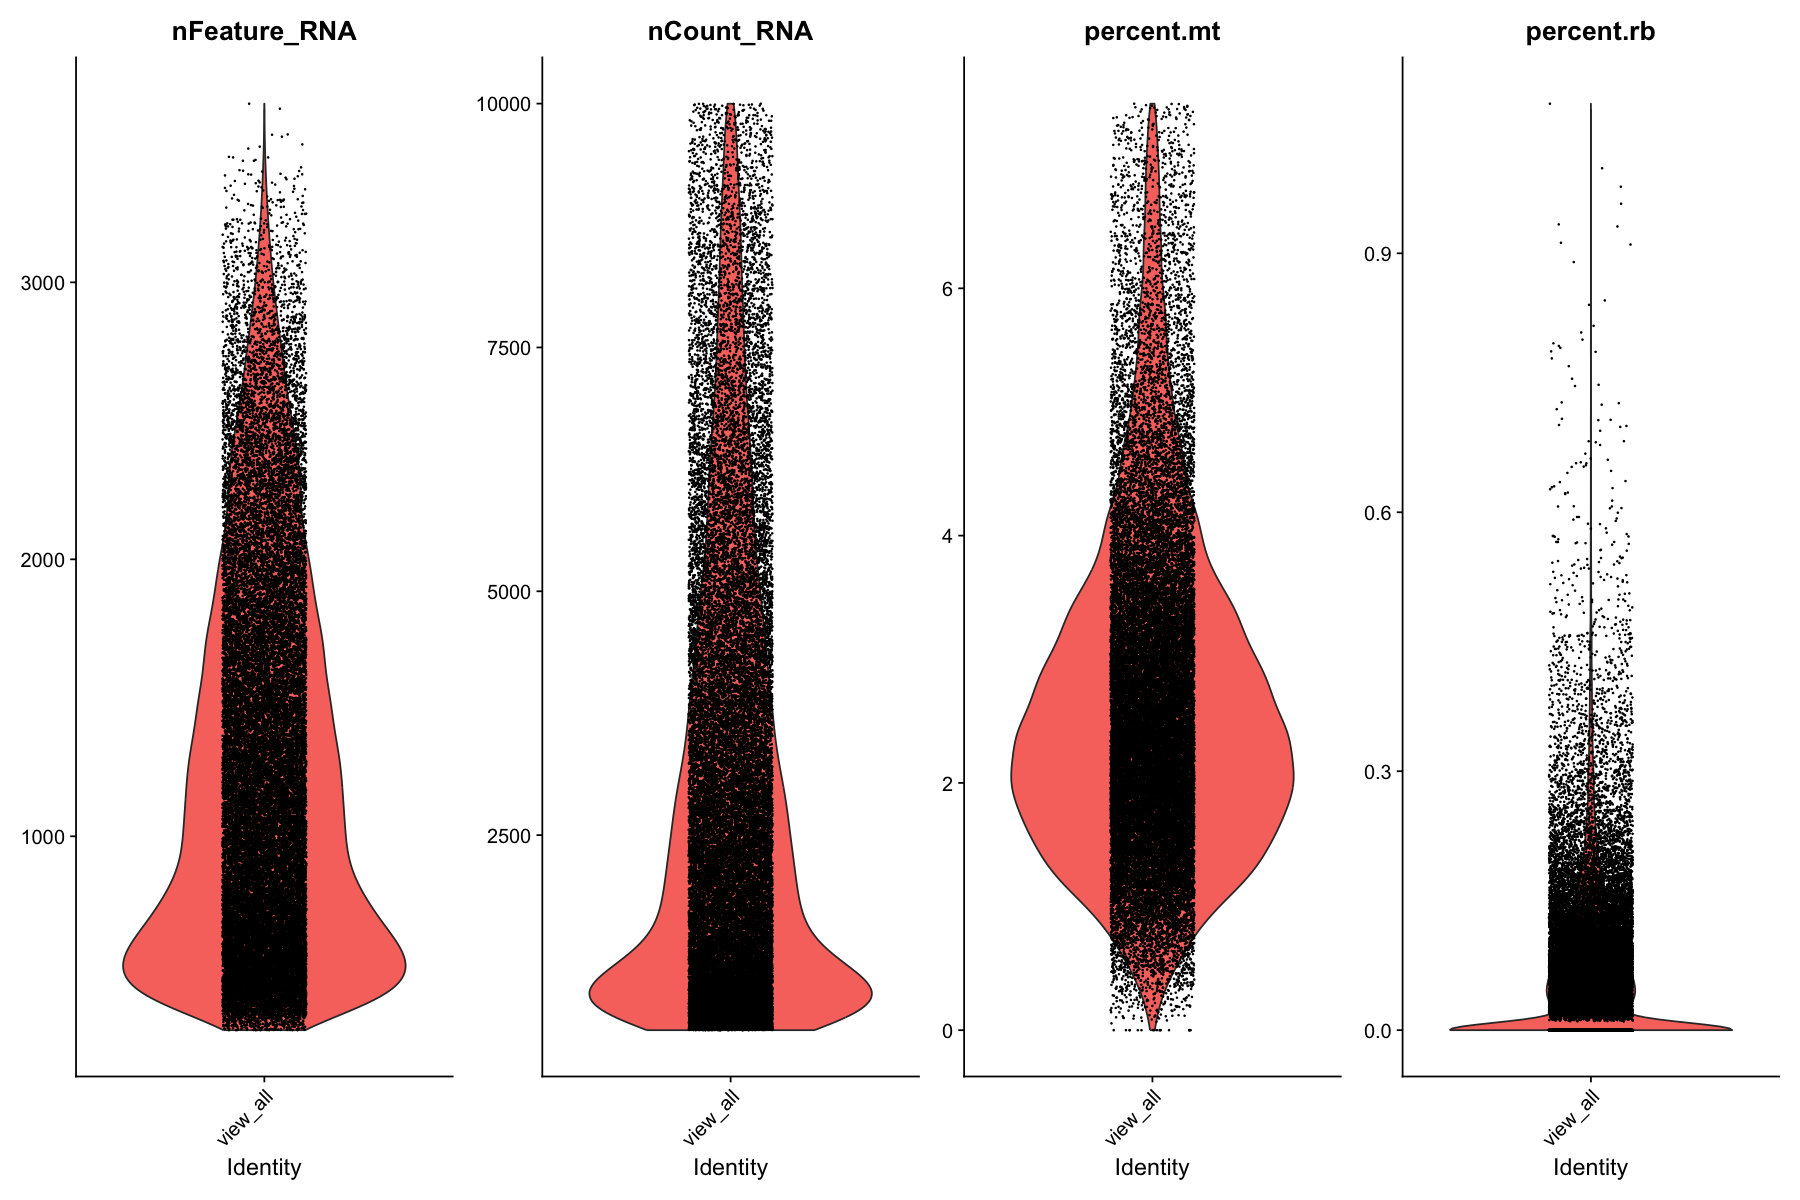

In [64]:
# Visualize QC metrics as a violin plot
VlnPlot(Filt_1_NOVOall_SRAT, features = c("nFeature_RNA", "nCount_RNA", "percent.mt", "percent.rb"), ncol = 4, split.by = "ALL", group.by = "ALL", raster=FALSE)

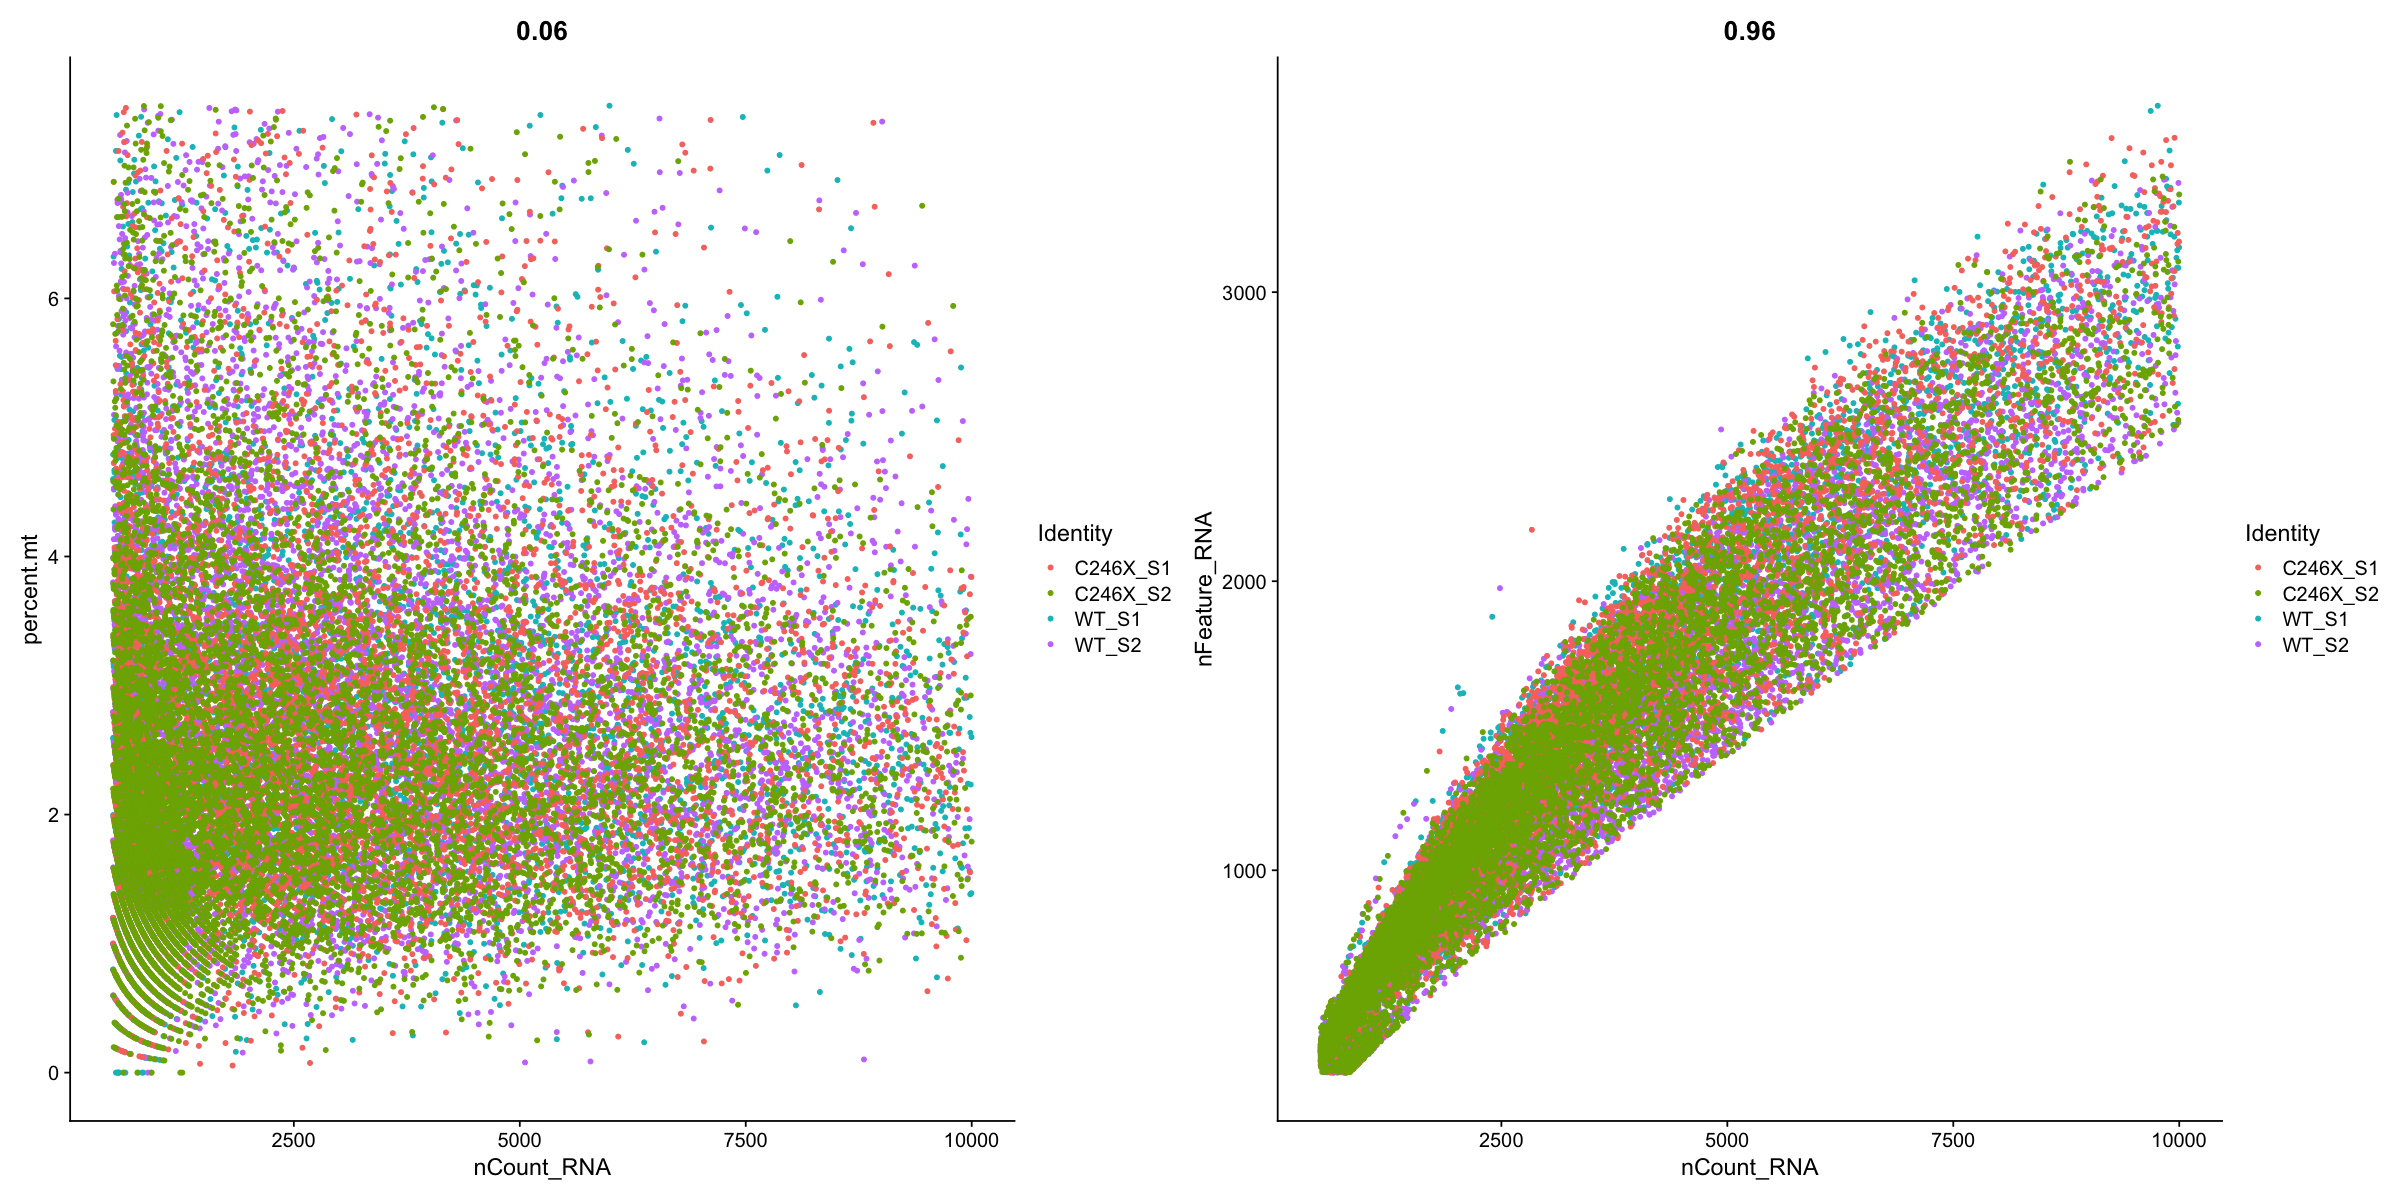

In [42]:
plot1_post <- FeatureScatter(Filt_1_NOVOall_SRAT, feature1 = "nCount_RNA", feature2 = "percent.mt", group.by = "orig.ident")
plot2_post <- FeatureScatter(Filt_1_NOVOall_SRAT, feature1 = "nCount_RNA", feature2 = "nFeature_RNA", group.by = "orig.ident")
plot1_post + plot2_post

## Number of cells post filtering 

In [65]:
Filt_1_NOVOall_SRAT_metadata = Filt_1_NOVOall_SRAT@meta.data

In [66]:
# add a sample column to have each sample as a different colour, add cell count col to count cells by sample and genotype
# change cells to orig.ident and vice versa and _S1 to _1 if using old data 
Filt_1_NOVOall_SRAT_metadata_final = Filt_1_NOVOall_SRAT_metadata %>% 
    mutate(sample = case_when(
                        str_detect(cells, "_S1") ~ "1",
                        str_detect(cells, "_S2") ~ "2",
                        str_detect(cells, "_S3") ~ "3",
                        str_detect(cells, "_S4") ~ "4")) %>%
    mutate(orig.ident = case_when(
                        str_detect(cells, "WT_S1") ~ "WT_S1",
                        str_detect(cells, "WT_S2") ~ "WT_S2",
                        str_detect(cells, "C246X_S1") ~ "C246X_S1",
                        str_detect(cells, "C246X_S2") ~ "C246X_S2")) %>%
    group_by(orig.ident) %>%  
    mutate(cell_count = n()) %>% # not using the count function bc all the other cols will disappear
    ungroup()

In [70]:
# save filtered metadata file
dir_filtmeta = readline(prompt = "Please enter file directory to save Filt_1_NOVOall_SRAT_metadata_final: ")
saveRDS(Filt_1_NOVOall_SRAT_metadata_final, dir_filtmeta)

Please enter file directory to save Filt_1_NOVOall_SRAT_metadata_final:  ../data_files2/Filt_1_NOVOall_SRAT_metadata_final.rds


In [62]:
# load filtered metadata file
Filt_1_NOVOall_SRAT_metadata_final = readRDS(dir_filtmeta)

## ***Plots after filtering***

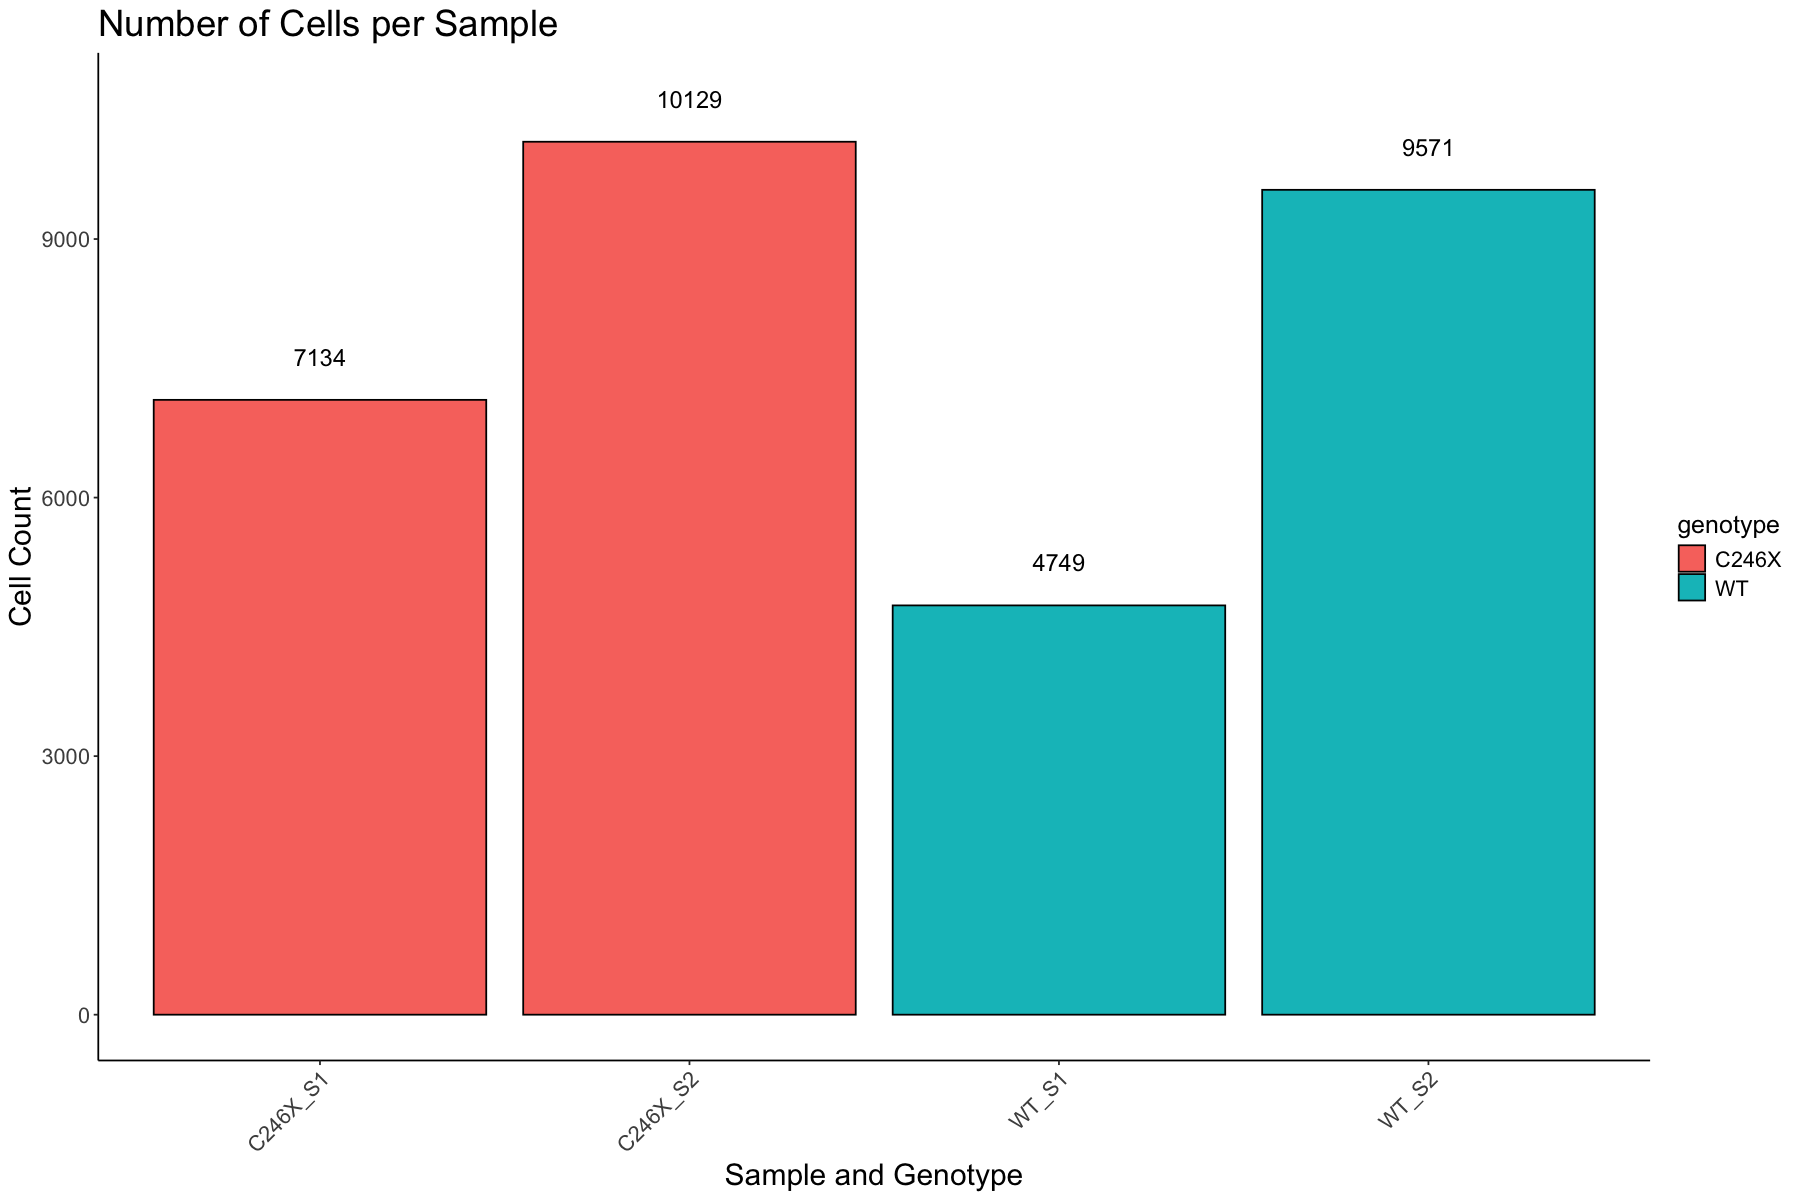

In [71]:
options(repr.plot.width=15, repr.plot.height=10)

Filt_1_NOVOall_SRAT_metadata_final %>%
  distinct(orig.ident, .keep_all = TRUE) %>% # remove the duplicate values so we can have one value per row, keep all cols
  ggplot(aes(x = orig.ident, y = cell_count)) + 
  	geom_col(aes(fill = genotype), color = "black") + 
    geom_text(aes(label = cell_count), nudge_y = 500, size = 5) +
    theme_classic() + 
    labs(x = "Sample and Genotype", y = "Cell Count") + 
    ggtitle("Number of Cells per Sample") + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 22))

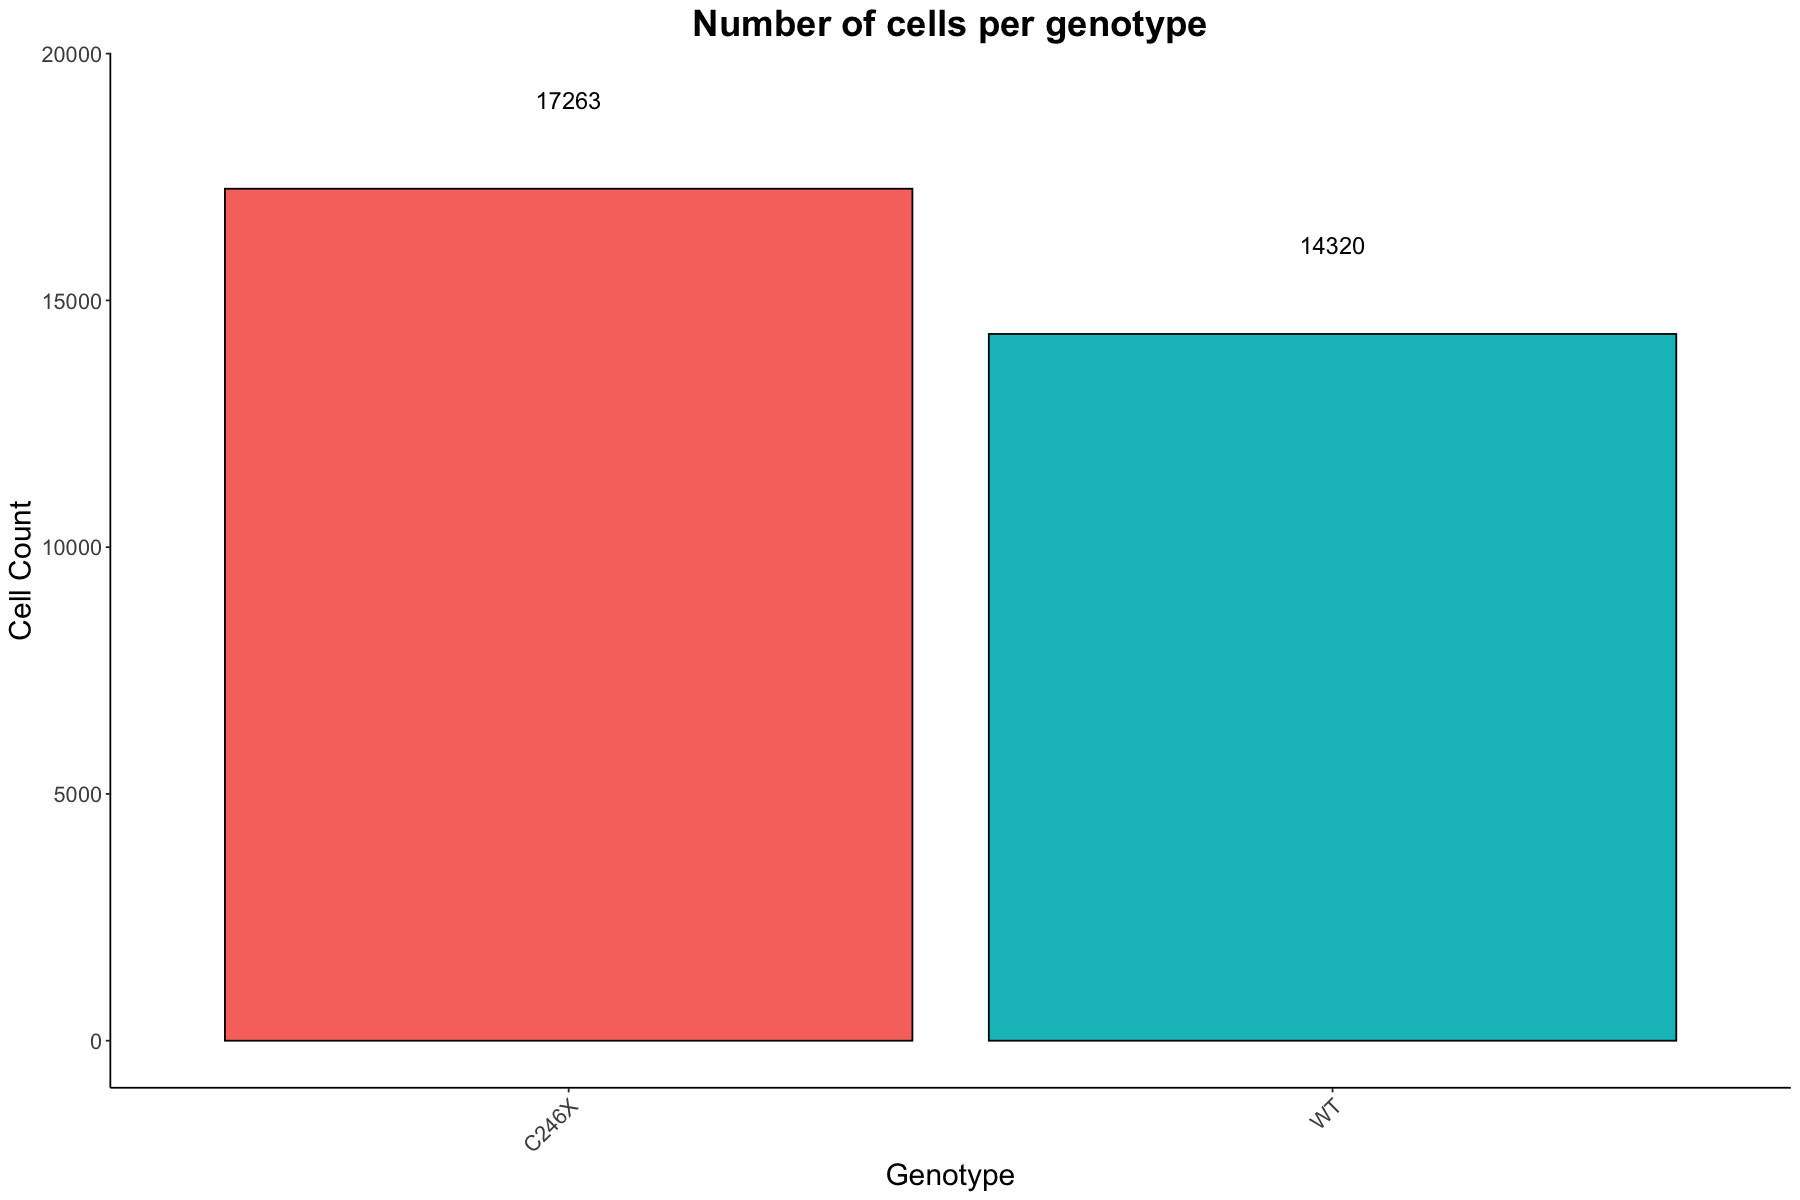

In [72]:
Filt_1_NOVOall_SRAT_metadata_final %>% 
  	ggplot(aes(x=genotype, fill=genotype)) + 
  	geom_bar(color = "black") +
    geom_text(aes(label = after_stat(count)), stat = "count", nudge_y = 1800, size = 5) +
  	theme_classic() +
  	theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
  	theme(plot.title = element_text(hjust=0.5, face="bold"), 
  	      legend.position = "none") +
    labs(x = "Genotype", y = "Cell Count") + 
  	ggtitle("Number of cells per genotype") + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 13),
          axis.text.y = element_text(size = 13),
          axis.title.x = element_text(size = 18),
          axis.title.y = element_text(size = 18),
          legend.text = element_text(size = 13),
          legend.title = element_text(size = 15),
          plot.title = element_text(size = 22))

## Doublet identification and trimming

In [73]:
Filt_1_NOVOall_SRAT_LAYERS = JoinLayers(Filt_1_NOVOall_SRAT)
NOVO_ALL_DOUBLETS_SCE <- as.SingleCellExperiment(Filt_1_NOVOall_SRAT_LAYERS)

# set seed for reproducibility (pass to BPPARAM arg bc we are dealing with multiple samples)
bp <- MulticoreParam(3, RNGseed=1234)
NOVO_ALL_DOUBLETS_SCE <- scDblFinder(NOVO_ALL_DOUBLETS_SCE, samples = "genotype", BPPARAM = bp) #dbr = multiplet_rate)
table(NOVO_ALL_DOUBLETS_SCE$scDblFinder.class)
NOVO_ALL_DOUBLETS_SCE@colData@listData %>% as.data.frame() %>% head()

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“Layer ‘data’ is empty”
Warning message:
“Layer ‘scale.data’ is empty”



singlet doublet 
  28839    2744 

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.rb,ALL,log10GenesPerUMI,mitoRatio,cells,genotype,ident,scDblFinder.sample,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
1,WT_S1,918,603,2.941176,0.00000000,view_all,0.9383952,0.02941176,WT_S1_AGCTGAGTC_ACCAGGTCA_AACAAGTGG,WT,AGCTGAGTC,WT,singlet,1.171964e-04,0.04636698,0.03565423
2,WT_S1,3575,1744,2.349650,0.11188811,view_all,0.9122698,0.02349650,WT_S1_CGCCAATGA_ATAGCGTGT_AACAAGTGG,WT,CGCCAATGA,WT,singlet,1.145718e-04,0.11732282,0.16736755
3,WT_S1,1393,498,1.435750,0.00000000,view_all,0.8579107,0.01435750,WT_S1_GCTTGAGGT_ATGCCTAAG_AACAAGTGG,WT,GCTTGAGGT,WT,singlet,9.357745e-05,0.11465715,0.07698938
4,WT_S1,3186,1390,2.448211,0.03138732,view_all,0.8971722,0.02448211,WT_S1_CCTTGAATC_CAATGCAAC_AACAAGTGG,WT,CCTTGAATC,WT,singlet,7.102425e-04,0.17163329,0.13928407
5,WT_S1,5489,1547,3.807615,0.07287302,view_all,0.8529205,0.03807615,WT_S1_TGCGGTTCT_CATCGGTTC_AACAAGTGG,WT,TGCGGTTCT,WT,singlet,1.473017e-03,0.09728320,0.14309924
6,WT_S1,2991,1424,3.075894,0.06686727,view_all,0.9072717,0.03075894,WT_S1_TGGAACGTA_CCAGTCCTA_AACAAGTGG,WT,TGGAACGTA,WT,doublet,9.856609e-01,0.58237799,0.26694180


### Return Doublet classification to seurat object

In [74]:
meta_scdblfinder <- NOVO_ALL_DOUBLETS_SCE@colData@listData %>% as.data.frame() %>% 
  dplyr::select(starts_with('scDblFinder')) # 'scDblFinder.class')
head(meta_scdblfinder)
rownames(meta_scdblfinder) <- NOVO_ALL_DOUBLETS_SCE@colData@rownames
head(meta_scdblfinder)
Filt_NOVOall_SRAT_SINGLETS <- AddMetaData(object = Filt_1_NOVOall_SRAT , metadata = meta_scdblfinder %>% dplyr::select('scDblFinder.class', ))
head(Filt_NOVOall_SRAT_SINGLETS)

,scDblFinder.sample,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score
,<fct>,<fct>,<dbl>,<dbl>,<dbl>
1,WT,singlet,1.171964e-04,0.04636698,0.03565423
2,WT,singlet,1.145718e-04,0.11732282,0.16736755
3,WT,singlet,9.357745e-05,0.11465715,0.07698938
4,WT,singlet,7.102425e-04,0.17163329,0.13928407
5,WT,singlet,1.473017e-03,0.09728320,0.14309924
6,WT,doublet,9.856609e-01,0.58237799,0.26694180


,scDblFinder.sample,scDblFinder.class,scDblFinder.score,scDblFinder.weighted,scDblFinder.cxds_score
,<fct>,<fct>,<dbl>,<dbl>,<dbl>
WT_S1_AGCTGAGTC_ACCAGGTCA_AACAAGTGG,WT,singlet,1.171964e-04,0.04636698,0.03565423
WT_S1_CGCCAATGA_ATAGCGTGT_AACAAGTGG,WT,singlet,1.145718e-04,0.11732282,0.16736755
WT_S1_GCTTGAGGT_ATGCCTAAG_AACAAGTGG,WT,singlet,9.357745e-05,0.11465715,0.07698938
WT_S1_CCTTGAATC_CAATGCAAC_AACAAGTGG,WT,singlet,7.102425e-04,0.17163329,0.13928407
WT_S1_TGCGGTTCT_CATCGGTTC_AACAAGTGG,WT,singlet,1.473017e-03,0.09728320,0.14309924
WT_S1_TGGAACGTA_CCAGTCCTA_AACAAGTGG,WT,doublet,9.856609e-01,0.58237799,0.26694180


,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.rb,ALL,log10GenesPerUMI,mitoRatio,cells,genotype,scDblFinder.class
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>
WT_S1_AGCTGAGTC_ACCAGGTCA_AACAAGTGG,WT_S1,918,603,2.941176,0.00000000,view_all,0.9383952,0.02941176,WT_S1_AGCTGAGTC_ACCAGGTCA_AACAAGTGG,WT,singlet
WT_S1_CGCCAATGA_ATAGCGTGT_AACAAGTGG,WT_S1,3575,1744,2.349650,0.11188811,view_all,0.9122698,0.02349650,WT_S1_CGCCAATGA_ATAGCGTGT_AACAAGTGG,WT,singlet
WT_S1_GCTTGAGGT_ATGCCTAAG_AACAAGTGG,WT_S1,1393,498,1.435750,0.00000000,view_all,0.8579107,0.01435750,WT_S1_GCTTGAGGT_ATGCCTAAG_AACAAGTGG,WT,singlet
WT_S1_CCTTGAATC_CAATGCAAC_AACAAGTGG,WT_S1,3186,1390,2.448211,0.03138732,view_all,0.8971722,0.02448211,WT_S1_CCTTGAATC_CAATGCAAC_AACAAGTGG,WT,singlet
WT_S1_TGCGGTTCT_CATCGGTTC_AACAAGTGG,WT_S1,5489,1547,3.807615,0.07287302,view_all,0.8529205,0.03807615,WT_S1_TGCGGTTCT_CATCGGTTC_AACAAGTGG,WT,singlet
WT_S1_TGGAACGTA_CCAGTCCTA_AACAAGTGG,WT_S1,2991,1424,3.075894,0.06686727,view_all,0.9072717,0.03075894,WT_S1_TGGAACGTA_CCAGTCCTA_AACAAGTGG,WT,doublet
WT_S1_CCTAGTCTT_CGTCATACC_AACAAGTGG,WT_S1,590,433,1.525424,0.00000000,view_all,0.9515080,0.01525424,WT_S1_CCTAGTCTT_CGTCATACC_AACAAGTGG,WT,singlet
WT_S1_ACGAAGCTC_CTAACCAGA_AACAAGTGG,WT_S1,6152,2219,3.039662,0.00000000,view_all,0.8831203,0.03039662,WT_S1_ACGAAGCTC_CTAACCAGA_AACAAGTGG,WT,singlet
WT_S1_GCGTAGTAA_CTAACCAGA_AACAAGTGG,WT_S1,902,468,1.552106,0.33259424,view_all,0.9035733,0.01552106,WT_S1_GCGTAGTAA_CTAACCAGA_AACAAGTGG,WT,singlet


### QC doublets vs singlets 

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


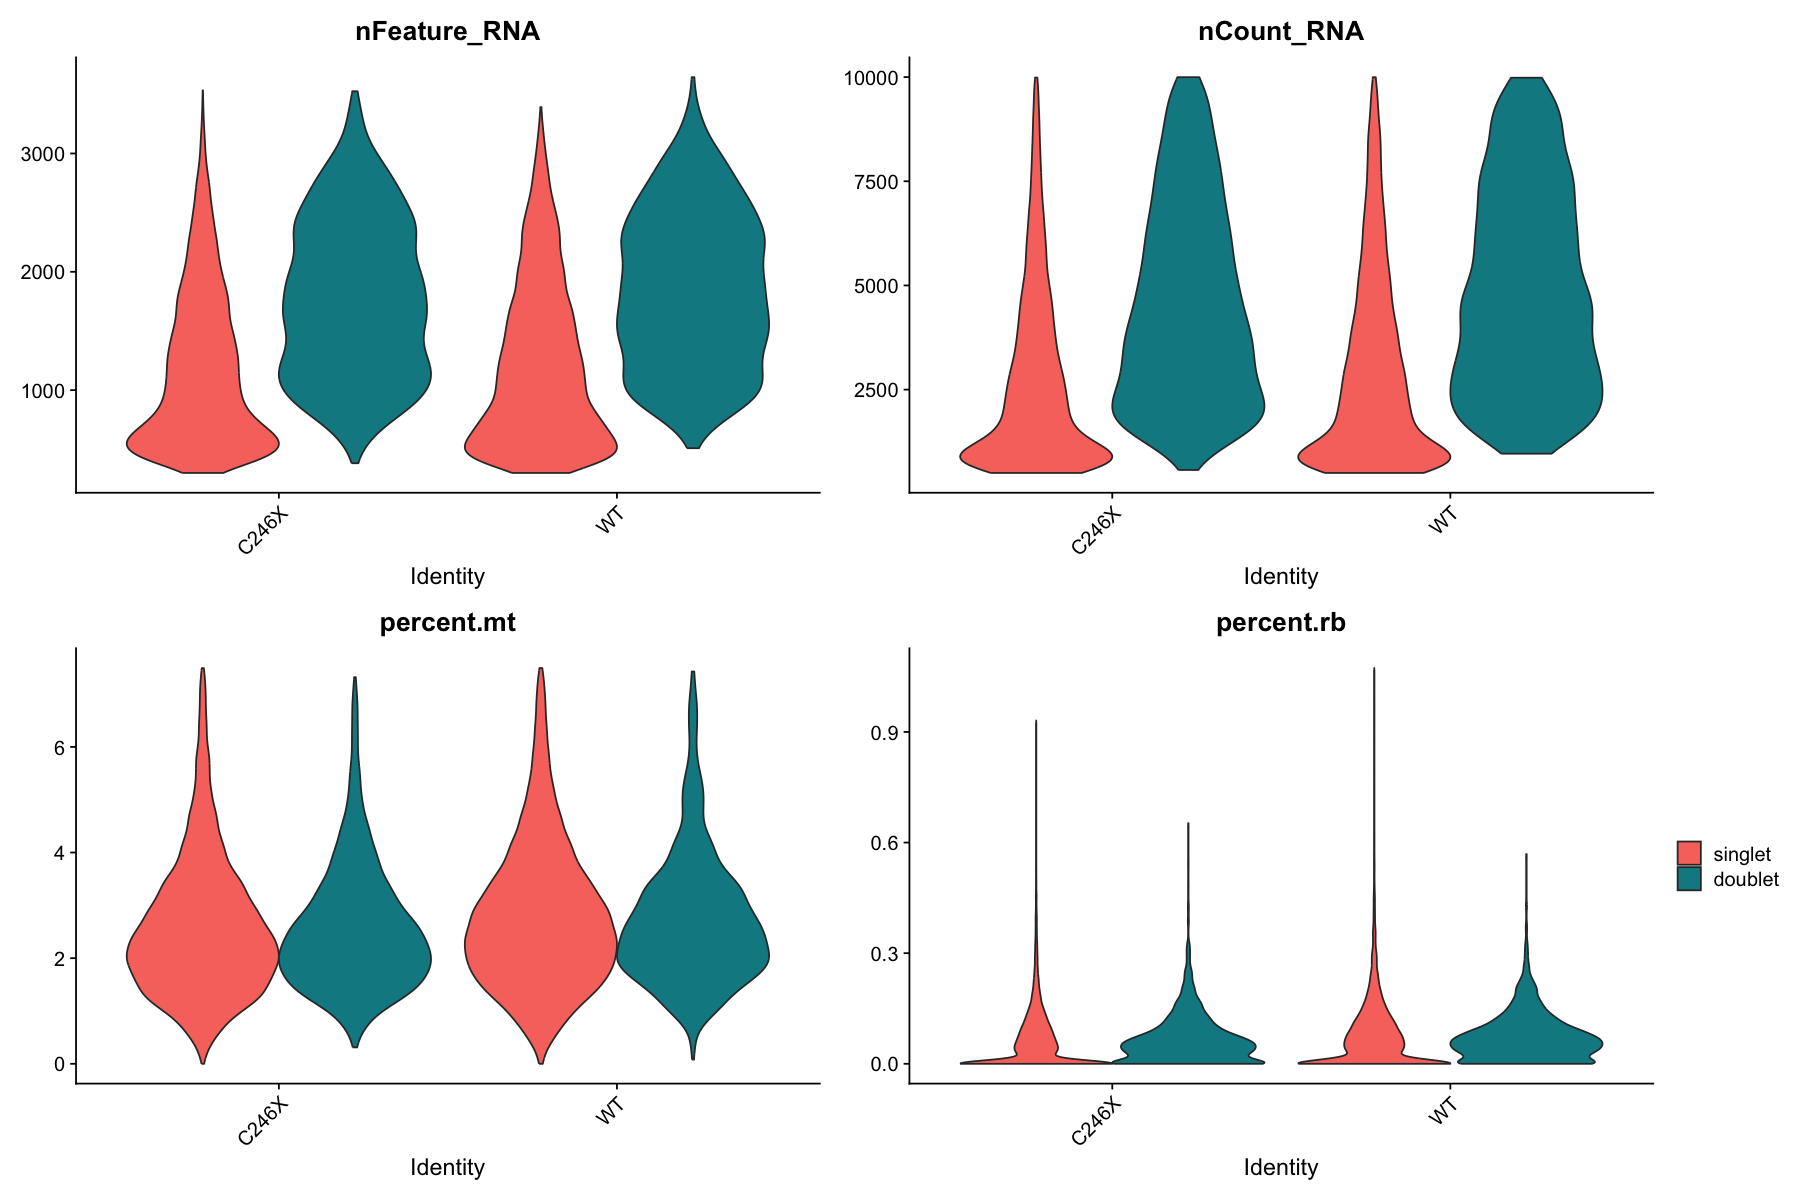

In [75]:
# Doublet stats
# Check how doublets singlets differ in QC measures per sample.
VlnPlot(Filt_NOVOall_SRAT_SINGLETS, group.by = 'genotype', split.by = "scDblFinder.class",
        features = c("nFeature_RNA", "nCount_RNA", "percent.mt", "percent.rb"), 
        ncol = 2, pt.size = 0) + 
        theme(legend.position = 'right')

### Summary table

In [76]:
doublets_summary <- Filt_NOVOall_SRAT_SINGLETS@meta.data %>% 
  group_by(genotype, scDblFinder.class) %>% 
  summarise(total_count = n(),.groups = 'drop') %>% as.data.frame() %>% ungroup() %>%
  group_by(genotype) %>%
  mutate(countT = sum(total_count)) %>%
  group_by(scDblFinder.class, .add = TRUE) %>%
  mutate(percent = paste0(round(100 * total_count/countT, 2),'%')) %>%
  dplyr::select(-countT)
doublets_summary

genotype,scDblFinder.class,total_count,percent
<chr>,<fct>,<int>,<chr>
C246X,singlet,15716,91.04%
C246X,doublet,1547,8.96%
WT,singlet,13123,91.64%
WT,doublet,1197,8.36%


### Remove the doublets

In [77]:
NOVOall_SRAT_TRIMMED <- subset(Filt_NOVOall_SRAT_SINGLETS, scDblFinder.class == 'singlet')


head(NOVOall_SRAT_TRIMMED)  

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.rb,ALL,log10GenesPerUMI,mitoRatio,cells,genotype,scDblFinder.class
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>
WT_S1_AGCTGAGTC_ACCAGGTCA_AACAAGTGG,WT_S1,918,603,2.941176,0.00000000,view_all,0.9383952,0.02941176,WT_S1_AGCTGAGTC_ACCAGGTCA_AACAAGTGG,WT,singlet
WT_S1_CGCCAATGA_ATAGCGTGT_AACAAGTGG,WT_S1,3575,1744,2.349650,0.11188811,view_all,0.9122698,0.02349650,WT_S1_CGCCAATGA_ATAGCGTGT_AACAAGTGG,WT,singlet
WT_S1_GCTTGAGGT_ATGCCTAAG_AACAAGTGG,WT_S1,1393,498,1.435750,0.00000000,view_all,0.8579107,0.01435750,WT_S1_GCTTGAGGT_ATGCCTAAG_AACAAGTGG,WT,singlet
WT_S1_CCTTGAATC_CAATGCAAC_AACAAGTGG,WT_S1,3186,1390,2.448211,0.03138732,view_all,0.8971722,0.02448211,WT_S1_CCTTGAATC_CAATGCAAC_AACAAGTGG,WT,singlet
WT_S1_TGCGGTTCT_CATCGGTTC_AACAAGTGG,WT_S1,5489,1547,3.807615,0.07287302,view_all,0.8529205,0.03807615,WT_S1_TGCGGTTCT_CATCGGTTC_AACAAGTGG,WT,singlet
WT_S1_CCTAGTCTT_CGTCATACC_AACAAGTGG,WT_S1,590,433,1.525424,0.00000000,view_all,0.9515080,0.01525424,WT_S1_CCTAGTCTT_CGTCATACC_AACAAGTGG,WT,singlet
WT_S1_ACGAAGCTC_CTAACCAGA_AACAAGTGG,WT_S1,6152,2219,3.039662,0.00000000,view_all,0.8831203,0.03039662,WT_S1_ACGAAGCTC_CTAACCAGA_AACAAGTGG,WT,singlet
WT_S1_GCGTAGTAA_CTAACCAGA_AACAAGTGG,WT_S1,902,468,1.552106,0.33259424,view_all,0.9035733,0.01552106,WT_S1_GCGTAGTAA_CTAACCAGA_AACAAGTGG,WT,singlet
WT_S1_TGCGGTTCT_GAAGAAGCC_AACAAGTGG,WT_S1,7739,2128,6.990567,0.10337253,view_all,0.8558090,0.06990567,WT_S1_TGCGGTTCT_GAAGAAGCC_AACAAGTGG,WT,singlet


In [82]:
# add in the sample column to the final df
NOVOall_SRAT_TRIMMED@meta.data = NOVOall_SRAT_TRIMMED@meta.data %>%
mutate(sample = case_when(
                        str_detect(cells, "_S1") ~ "1",
                        str_detect(cells, "_S2") ~ "2",
                        str_detect(cells, "_S3") ~ "3",
                        str_detect(cells, "_S4") ~ "4"))

In [84]:
# save the trimmed file
user_file_directory_trimmed = readline(prompt = "Please enter file directory to save NOVOall_SRAT_TRIMMED: ")
saveRDS(NOVOall_SRAT_TRIMMED, file = user_file_directory_trimmed) # remember to add .rds extension after file name

Please enter file directory to save NOVOall_SRAT_TRIMMED:  ../data_files2/NOVOall_SRAT_TRIMMED.rds
